# Phyloseq analysis
- combo from Nikea https://github.com/nikeaulrich/DR_SCTLD/blob/main/DR_phyloseq.ipynb and my old https://github.com/brookewicz/CBC_metagenomics/blob/main/pstr/pstr_taxonomy_plots.ipynb

https://www.bioconductor.org/packages/release/bioc/html/phyloseq.html

Need to make a phyloseq object to run lefse \
https://rdrr.io/github/yiluheihei/microbiomeMarker/man/run_lefse.html

In [2]:
getwd()

[1] "/project/pi_sarah_gignouxwolfsohn_uml_edu/brooke/CBC_metagenomics/all_sctld"

In [3]:
# see installation from 4Taxa_Trials in PSTR

In [4]:
install.packages('taxonomizr')

also installing the dependency ‘RSQLite’


Warning message in install.packages("taxonomizr"):
“installation of package ‘RSQLite’ had non-zero exit status”
Warning message in install.packages("taxonomizr"):
“installation of package ‘taxonomizr’ had non-zero exit status”
Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [5]:
library(tidyverse)
library(vegan)
library(dplyr)
library(phyloseq)
#library(VennDiagram)
library("DESeq2")
library(RColorBrewer)
library(ggplot2)
library(cowplot)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute

Loading required package: lattice

This is vegan 2.6-5

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:s

## Upload Data

In [6]:
setwd("/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/taxonomy/kraken2_pluspf/bracken")

### Taxonomy 

In [7]:
taxa = read.csv('otu_id_species.csv',header=TRUE)
head(taxa)

,taxonomy_id,name,taxonomy_lvl
,<int>,<chr>,<chr>
1,3021011,Vibrio sp. SCSIO 43137,S
2,2819098,Vibrio sp. SCSIO 43153,S
3,2819101,Vibrio sp. SCSIO 43136,S
4,2912314,Vibrio sp. JC009,S
5,2751178,Vibrio sp. B1FLJ16,S
6,2751176,Vibrio sp. B1ASS3,S


In [8]:
# remove taxa level col
taxa$taxonomy_lvl <- NULL 
# change taxa table names
colnames(taxa) <- c("otuid","species")

In [9]:
head(taxa)

,otuid,species
,<int>,<chr>
1,3021011,Vibrio sp. SCSIO 43137
2,2819098,Vibrio sp. SCSIO 43153
3,2819101,Vibrio sp. SCSIO 43136
4,2912314,Vibrio sp. JC009
5,2751178,Vibrio sp. B1FLJ16
6,2751176,Vibrio sp. B1ASS3


In [10]:
# make the index the otu ids
row.names(taxa) <- taxa$otuid
taxa$otuid <- NULL
head(taxa)

,species
,<chr>
3021011,Vibrio sp. SCSIO 43137
2819098,Vibrio sp. SCSIO 43153
2819101,Vibrio sp. SCSIO 43136
2912314,Vibrio sp. JC009
2751178,Vibrio sp. B1FLJ16
2751176,Vibrio sp. B1ASS3


In [43]:
wd()

[1] "/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/taxonomy/kraken2_pluspf/bracken"

In [60]:
## add in full taxonomy from krakentools (2.1OTUtable)
taxa_full<-read.csv("txt_files/bracken_S.combined.mpa", sep = '\t') %>% select(1)
head(taxa_full)

,X.Classification
,<chr>
1,d__Bacteria
2,d__Bacteria|f__Candidatus_Chazhemtobacteraceae
3,d__Bacteria|f__Candidatus_Chazhemtobacteraceae|g__Candidatus_Chazhemtobacterium
4,d__Bacteria|f__Candidatus_Chazhemtobacteraceae|g__Candidatus_Chazhemtobacterium|s__Candidatus_Chazhemtobacterium_aquaticus
5,d__Bacteria|p__Candidatus_Bipolaricaulota
6,d__Bacteria|p__Candidatus_Bipolaricaulota|c__Candidatus_Bipolaricaulia


In [61]:
taxa_full[73,1]

[1] "d__Bacteria|k__Thermotogati|p__Synergistota|c__Synergistia|o__Synergistales|f__Aminithiophilaceae|g__Aminithiophilus|s__Aminithiophilus_ramosus"

In [62]:
taxonomy_full<-taxa_full %>%
  separate(
    col = X.Classification, 
    into = c("domain","kingdom", "phylum", "slass", "order", "family", "genus", "species"), 
    sep = "\\|") %>%
  mutate(across(everything(), ~ gsub("^[a-z]__", "", .)))

Warning message:
“Expected 8 pieces. Missing pieces filled with `NA` in 7291 rows [1, 2, 3, 4, 5,
6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, ...].”


In [84]:
# filter for species-level matches
# and replace _ for spaces 
sp_full<-taxonomy_full %>%
    filter(!is.na(species)) %>%
    mutate(species = str_replace_all(species,"_"," "))
head(sp_full)

,domain,kingdom,phylum,slass,order,family,genus,species
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Bacteria,Thermotogati,Synergistota,Synergistia,Synergistales,Aminithiophilaceae,Aminithiophilus,Aminithiophilus ramosus
2,Bacteria,Thermotogati,Synergistota,Synergistia,Synergistales,Aminiphilaceae,Aminirod,Aminirod propionatiphilus
3,Bacteria,Thermotogati,Synergistota,Synergistia,Synergistales,Synergistaceae,Thermanaerovibrio,Thermanaerovibrio acidaminovorans
4,Bacteria,Thermotogati,Synergistota,Synergistia,Synergistales,Synergistaceae,Thermanaerovibrio,Thermanaerovibrio velox
5,Bacteria,Thermotogati,Synergistota,Synergistia,Synergistales,Synergistaceae,Aminomonas,Aminomonas paucivorans
6,Bacteria,Thermotogati,Synergistota,Synergistia,Synergistales,Synergistaceae,Cloacibacillus,Cloacibacillus evryensis


In [96]:
unique(merged_taxa$domain)

[1] "Bacteria"  NA          "Eukaryota" "Archaea"

In [87]:
# merge with species taxa table
merged_taxa<-taxa %>%
    left_join(sp_full, by = "species")

In [103]:
head(merged_taxa)

,species,domain,kingdom,phylum,slass,order,family,genus
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Vibrio sp. SCSIO 43137,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
2,Vibrio sp. SCSIO 43153,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
3,Vibrio sp. SCSIO 43136,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
4,Vibrio sp. JC009,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
5,Vibrio sp. B1FLJ16,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
6,Vibrio sp. B1ASS3,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio


In [107]:
# help from gemini to clean up and add missing genus names
merged_taxa_clean <- merged_taxa %>%
    # Extract Genus from first word of Species name if Genus is NA
    mutate(genus = ifelse(is.na(genus),
                   word(species, 1), 
                   genus)) 
# %>%
#   # Fill missing ranks hierarchically with clear placeholders
#   mutate(
#     phylum = ifelse(is.na(phylum), paste0("Unclassified_", domain), phylum),
#     class  = ifelse(is.na(class), paste0("Unclassified_", phylum), class),
#     order  = ifelse(is.na(order), paste0("Unclassified_", class), order),
#     family = ifelse(is.na(family), paste0("Unclassified_", order), family),
#     genus = ifelse(is.na(genus), paste0("Unclassified_", family), genus)
#   )

In [110]:
str(merged_taxa_clean)

'data.frame':	15891 obs. of  8 variables:
 $ species: chr  "Vibrio sp. SCSIO 43137" "Vibrio sp. SCSIO 43153" "Vibrio sp. SCSIO 43136" "Vibrio sp. JC009" ...
 $ domain : chr  "Bacteria" "Bacteria" "Bacteria" "Bacteria" ...
 $ kingdom: chr  "Pseudomonadati" "Pseudomonadati" "Pseudomonadati" "Pseudomonadati" ...
 $ phylum : chr  "Pseudomonadota" "Pseudomonadota" "Pseudomonadota" "Pseudomonadota" ...
 $ slass  : chr  "Gammaproteobacteria" "Gammaproteobacteria" "Gammaproteobacteria" "Gammaproteobacteria" ...
 $ order  : chr  "Vibrionales" "Vibrionales" "Vibrionales" "Vibrionales" ...
 $ family : chr  "Vibrionaceae" "Vibrionaceae" "Vibrionaceae" "Vibrionaceae" ...
 $ genus  : chr  "Vibrio" "Vibrio" "Vibrio" "Vibrio" ...


In [111]:
#convert to character matrix to create phyloseq objects 
taxonomy <- as.matrix(taxa)

# check structure
str(taxonomy)    

 chr [1:15891, 1] "Vibrio sp. SCSIO 43137" "Vibrio sp. SCSIO 43153" ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:15891] "3021011" "2819098" "2819101" "2912314" ...
  ..$ : chr "species"


### OTU Table

In [13]:
#read in normalized otu table
otu = read.csv('otu_normtable_species.csv',header=TRUE)
head(otu)

,X,X052022_BEL_CBC_T1_10_PSTR,X052022_BEL_CBC_T1_11_PSTR,X052022_BEL_CBC_T1_12_MCAV,X052022_BEL_CBC_T1_13_MCAV,X052022_BEL_CBC_T1_1_PAST,X052022_BEL_CBC_T1_34_PAST,X052022_BEL_CBC_T1_35_OANN,X052022_BEL_CBC_T1_39_MCAV,X052022_BEL_CBC_T1_40_MCAV,⋯,X122022_BEL_CBC_T4_38_MCAV,X122022_BEL_CBC_T4_4_PSTR,X122022_BEL_CBC_T4_5_MCAV,X122022_BEL_CBC_T4_6_MCAV,X122022_BEL_CBC_T4_8_PSTR,X122022_BEL_CBC_T4_9_OFAV,X7_11_Neg,X7_3_Neg,Negative_extract_11.2.24,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3021011,23887.8267,108.23239,2959.21739,0.00000,148.8358,34.00636,237.959,13396.95278,537.50643,⋯,0.0000,17.46868,0.00000,51.64680,23.19476,176.82509,0.000000,0,0.00000,198940.566
2,2819098,3661.7429,359.79957,49.47990,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,33.68270,0.00000,42.40193,1.772594,0,1.60177,7719.019
3,2819101,468.5301,353.94917,92.57530,0.00000,0.0000,32.21655,840.451,141.47182,0.00000,⋯,1156.4878,112.75237,1031.86757,368.26416,132.92380,378.00873,0.000000,0,0.00000,61046.623
4,2912314,178.4018,67.27959,124.49782,0.00000,176.7425,35.79617,0.000,282.94364,76.78663,⋯,141.0351,19.05674,61.98498,46.03302,15.16580,63.15182,0.000000,0,0.00000,17072.805
5,2751178,163.9855,172.58678,44.69152,91.32361,0.0000,41.16559,0.000,64.30537,0.00000,⋯,131.6328,50.81797,69.27733,152.69490,67.80006,128.10797,0.000000,0,0.00000,20061.923
6,2751176,349.5955,3881.74003,162.80484,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,267.21607,23.19476,251.70510,0.000000,0,0.00000,18629.572


In [14]:
# rename first col as otu
names(otu)[1] <- "otu"
head(otu)
dim(otu)

,otu,X052022_BEL_CBC_T1_10_PSTR,X052022_BEL_CBC_T1_11_PSTR,X052022_BEL_CBC_T1_12_MCAV,X052022_BEL_CBC_T1_13_MCAV,X052022_BEL_CBC_T1_1_PAST,X052022_BEL_CBC_T1_34_PAST,X052022_BEL_CBC_T1_35_OANN,X052022_BEL_CBC_T1_39_MCAV,X052022_BEL_CBC_T1_40_MCAV,⋯,X122022_BEL_CBC_T4_38_MCAV,X122022_BEL_CBC_T4_4_PSTR,X122022_BEL_CBC_T4_5_MCAV,X122022_BEL_CBC_T4_6_MCAV,X122022_BEL_CBC_T4_8_PSTR,X122022_BEL_CBC_T4_9_OFAV,X7_11_Neg,X7_3_Neg,Negative_extract_11.2.24,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3021011,23887.8267,108.23239,2959.21739,0.00000,148.8358,34.00636,237.959,13396.95278,537.50643,⋯,0.0000,17.46868,0.00000,51.64680,23.19476,176.82509,0.000000,0,0.00000,198940.566
2,2819098,3661.7429,359.79957,49.47990,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,33.68270,0.00000,42.40193,1.772594,0,1.60177,7719.019
3,2819101,468.5301,353.94917,92.57530,0.00000,0.0000,32.21655,840.451,141.47182,0.00000,⋯,1156.4878,112.75237,1031.86757,368.26416,132.92380,378.00873,0.000000,0,0.00000,61046.623
4,2912314,178.4018,67.27959,124.49782,0.00000,176.7425,35.79617,0.000,282.94364,76.78663,⋯,141.0351,19.05674,61.98498,46.03302,15.16580,63.15182,0.000000,0,0.00000,17072.805
5,2751178,163.9855,172.58678,44.69152,91.32361,0.0000,41.16559,0.000,64.30537,0.00000,⋯,131.6328,50.81797,69.27733,152.69490,67.80006,128.10797,0.000000,0,0.00000,20061.923
6,2751176,349.5955,3881.74003,162.80484,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,267.21607,23.19476,251.70510,0.000000,0,0.00000,18629.572


[1] 15892   224

In [15]:
#remove X's from headers
names(otu) <- sub("^X", "", names(otu))
otu_table=as.data.frame(otu)
head(otu_table)

,otu,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,⋯,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3021011,23887.8267,108.23239,2959.21739,0.00000,148.8358,34.00636,237.959,13396.95278,537.50643,⋯,0.0000,17.46868,0.00000,51.64680,23.19476,176.82509,0.000000,0,0.00000,198940.566
2,2819098,3661.7429,359.79957,49.47990,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,33.68270,0.00000,42.40193,1.772594,0,1.60177,7719.019
3,2819101,468.5301,353.94917,92.57530,0.00000,0.0000,32.21655,840.451,141.47182,0.00000,⋯,1156.4878,112.75237,1031.86757,368.26416,132.92380,378.00873,0.000000,0,0.00000,61046.623
4,2912314,178.4018,67.27959,124.49782,0.00000,176.7425,35.79617,0.000,282.94364,76.78663,⋯,141.0351,19.05674,61.98498,46.03302,15.16580,63.15182,0.000000,0,0.00000,17072.805
5,2751178,163.9855,172.58678,44.69152,91.32361,0.0000,41.16559,0.000,64.30537,0.00000,⋯,131.6328,50.81797,69.27733,152.69490,67.80006,128.10797,0.000000,0,0.00000,20061.923
6,2751176,349.5955,3881.74003,162.80484,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,267.21607,23.19476,251.70510,0.000000,0,0.00000,18629.572


In [16]:
#reorder columns from list file (just concatenated the IDs together in the order I wanted
# column_list <- readLines("DR_column_order.txt")
# otu_table <- otu_table[, column_list]
# head(otu_table)

In [17]:
# make the index the otus
row.names(otu_table) <- otu_table$otu
otu_table$otu <- NULL
head(otu_table)

,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,052022_BEL_CBC_T1_41_OANN,⋯,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24,Sum
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3021011,23887.8267,108.23239,2959.21739,0.00000,148.8358,34.00636,237.959,13396.95278,537.50643,0.0000,⋯,0.0000,17.46868,0.00000,51.64680,23.19476,176.82509,0.000000,0,0.00000,198940.566
2819098,3661.7429,359.79957,49.47990,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,0.0000,⋯,0.0000,0.00000,0.00000,33.68270,0.00000,42.40193,1.772594,0,1.60177,7719.019
2819101,468.5301,353.94917,92.57530,0.00000,0.0000,32.21655,840.451,141.47182,0.00000,1251.3442,⋯,1156.4878,112.75237,1031.86757,368.26416,132.92380,378.00873,0.000000,0,0.00000,61046.623
2912314,178.4018,67.27959,124.49782,0.00000,176.7425,35.79617,0.000,282.94364,76.78663,0.0000,⋯,141.0351,19.05674,61.98498,46.03302,15.16580,63.15182,0.000000,0,0.00000,17072.805
2751178,163.9855,172.58678,44.69152,91.32361,0.0000,41.16559,0.000,64.30537,0.00000,166.1942,⋯,131.6328,50.81797,69.27733,152.69490,67.80006,128.10797,0.000000,0,0.00000,20061.923
2751176,349.5955,3881.74003,162.80484,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,0.0000,⋯,0.0000,0.00000,0.00000,267.21607,23.19476,251.70510,0.000000,0,0.00000,18629.572


In [18]:
# sort by most abundant OTUs
otus_sorted <- otu_table[order(rowSums(otu_table), decreasing = TRUE), ]
head(otus_sorted)

,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,052022_BEL_CBC_T1_41_OANN,⋯,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24,Sum
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Total_reads,554927.0000,341857.0000,626517.000,153301.0000,107501.0000,558719.0000,197513.0000,233262.000,130231.00,102290.0000,⋯,212713.0000,1259397.00,274260.000,890665.0000,1120943.000,1.108440e+06,1.636020e+07,4494966.00,1.061326e+07,287599902
2057741,646.9319,912.6623,179529.047,74559.2005,179021.5905,14756.9709,6060.3606,105130.711,325475.50,2062.7627,⋯,40185.6022,219368.48,28706.337,7715.5833,269447.242,2.435856e+02,3.674441e+05,308665.07,1.248429e+04,17997644
1747,264.8997,857.0835,19008.263,5838.1876,63990.1024,2822.5280,678.4364,2958.047,11295.31,918.9559,⋯,12777.7804,93354.20,2140.305,191.9914,9283.255,1.101548e+03,1.559150e+03,6292.15,6.112587e+05,4938561
2066072,33593.6078,29992.0727,12615.779,1245.9149,976.7351,141.3949,12282.7358,22579.760,31244.48,18995.0142,⋯,42564.3943,15603.50,43342.084,57275.1820,17986.642,3.924073e+04,2.506082e+00,0.00,3.109318e+00,3624902
1929291,153.1733,175.5120,164.401,182.6472,111.6269,1583.9805,222.7701,39916.489,0.00,0.0000,⋯,404.3006,42190.03,21403.048,8595.8245,62173.545,6.946700e+01,1.412656e+05,111969.70,2.167101e+01,2672541
1325120,88.2999,117.0080,30699.885,21461.0472,21562.5901,2040.3817,531.6106,31188.106,17660.93,215.0748,⋯,13370.1278,24553.02,5079.122,798.2799,24815.713,8.480387e+01,2.769648e+04,39314.87,4.633826e+03,2465154


In [19]:
#remove total reads row
otus_sorted <- otus_sorted[-1, ]

# remove sum col
otus_sorted$Sum <- NULL

head(otus_sorted)
dim (otus_sorted)

,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,052022_BEL_CBC_T1_41_OANN,⋯,122022_BEL_CBC_T4_36_PSTR,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2057741,646.9319,912.6623,179529.047,74559.2005,179021.5905,14756.9709,6060.3606,105130.711,325475.50,2062.7627,⋯,9859.4883,40185.6022,219368.476,28706.337,7715.5833,269447.242,243.58558,3.674441e+05,308665.07,1.248429e+04
1747,264.8997,857.0835,19008.263,5838.1876,63990.1024,2822.5280,678.4364,2958.047,11295.31,918.9559,⋯,404.6615,12777.7804,93354.200,2140.305,191.9914,9283.255,1101.54812,1.559150e+03,6292.15,6.112587e+05
2066072,33593.6078,29992.0727,12615.779,1245.9149,976.7351,141.3949,12282.7358,22579.760,31244.48,18995.0142,⋯,55624.4130,42564.3943,15603.499,43342.084,57275.1820,17986.642,39240.73473,2.506082e+00,0.00,3.109318e+00
1929291,153.1733,175.5120,164.401,182.6472,111.6269,1583.9805,222.7701,39916.489,0.00,0.0000,⋯,4769.4066,404.3006,42190.032,21403.048,8595.8245,62173.545,69.46700,1.412656e+05,111969.70,2.167101e+01
1325120,88.2999,117.0080,30699.885,21461.0472,21562.5901,2040.3817,531.6106,31188.106,17660.93,215.0748,⋯,1987.6769,13370.1278,24553.020,5079.122,798.2799,24815.713,84.80387,2.769648e+04,39314.87,4.633826e+03
1590,470.3321,558.7131,21148.668,14357.3754,11088.2689,2627.4388,460.7292,10190.258,21070.25,479.0302,⋯,1325.9663,10751.5761,6156.915,3121.126,799.4027,6145.718,490.77983,1.388436e+04,26322.11,1.858421e+04


[1] 15891   222

In [20]:
# Convert to matrix
otus=as.matrix(otus_sorted)
head(otus)

,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,052022_BEL_CBC_T1_41_OANN,⋯,122022_BEL_CBC_T4_36_PSTR,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24
2057741,646.9319,912.6623,179529.047,74559.2005,179021.5905,14756.9709,6060.3606,105130.711,325475.50,2062.7627,⋯,9859.4883,40185.6022,219368.476,28706.337,7715.5833,269447.242,243.58558,3.674441e+05,308665.07,1.248429e+04
1747,264.8997,857.0835,19008.263,5838.1876,63990.1024,2822.5280,678.4364,2958.047,11295.31,918.9559,⋯,404.6615,12777.7804,93354.200,2140.305,191.9914,9283.255,1101.54812,1.559150e+03,6292.15,6.112587e+05
2066072,33593.6078,29992.0727,12615.779,1245.9149,976.7351,141.3949,12282.7358,22579.760,31244.48,18995.0142,⋯,55624.4130,42564.3943,15603.499,43342.084,57275.1820,17986.642,39240.73473,2.506082e+00,0.00,3.109318e+00
1929291,153.1733,175.5120,164.401,182.6472,111.6269,1583.9805,222.7701,39916.489,0.00,0.0000,⋯,4769.4066,404.3006,42190.032,21403.048,8595.8245,62173.545,69.46700,1.412656e+05,111969.70,2.167101e+01
1325120,88.2999,117.0080,30699.885,21461.0472,21562.5901,2040.3817,531.6106,31188.106,17660.93,215.0748,⋯,1987.6769,13370.1278,24553.020,5079.122,798.2799,24815.713,84.80387,2.769648e+04,39314.87,4.633826e+03
1590,470.3321,558.7131,21148.668,14357.3754,11088.2689,2627.4388,460.7292,10190.258,21070.25,479.0302,⋯,1325.9663,10751.5761,6156.915,3121.126,799.4027,6145.718,490.77983,1.388436e+04,26322.11,1.858421e+04


### Metadata

In [21]:
getwd()

[1] "/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/taxonomy/kraken2_pluspf/bracken"

In [22]:
#read in metadata
# in pstr version i directly uploaded cbc samples and cbc colony data
# going to try my already merged meta+sampleid table that I made in read_counts..

metadata=read.csv('/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/reads_meta.csv', header=TRUE)

# index the SampleIDs and remove raw read counts
metadata$raw <- NULL
metadata$trimmed <- NULL
metadata$pct_yield <- NULL

# row.names(metadata) <- metadata$sampleid
# metadata$sampleid <- NULL
head(metadata)

,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,colony_id,group
,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
1,052022_BEL_CBC_T1_10_PSTR,52022,5/21/22,CBC30N,1,4,PSTR,10,Diseased_Margin,T1_4_PSTR,52022_PSTR_Diseased_Margin
2,052022_BEL_CBC_T1_11_PSTR,52022,5/21/22,CBC30N,1,4,PSTR,11,Diseased_Tissue,T1_4_PSTR,52022_PSTR_Diseased_Tissue
3,052022_BEL_CBC_T1_12_MCAV,52022,5/21/22,CBC30N,1,8,MCAV,12,Diseased_Margin,T1_8_MCAV,52022_MCAV_Diseased_Margin
4,052022_BEL_CBC_T1_13_MCAV,52022,5/21/22,CBC30N,1,8,MCAV,13,Diseased_Tissue,T1_8_MCAV,52022_MCAV_Diseased_Tissue
5,052022_BEL_CBC_T1_1_PAST,52022,5/21/22,CBC30N,1,2,PAST,1,Healthy,T1_2_PAST,52022_PAST_Healthy
6,052022_BEL_CBC_T1_34_PAST,52022,5/21/22,CBC30N,1,21,PAST,34,Healthy,T1_21_PAST,52022_PAST_Healthy


In [23]:
# create list of colony IDs in sample set 
colony_list<-unique(metadata$colony_id)
# NAs are all negative controls

In [24]:
unique(metadata$Month_year)
# what months do we need conditions from colonydata

[1]  52022  62019 102019 122022     NA

In [25]:
# upload colony data to add Resistant vs Susceptible category

colony=read.csv('/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/CBC_ColonyData.csv',header=TRUE)

In [26]:
# add colony id and filter for target colonies
colony$colony_id<-paste0("T", colony$TransectNum, "_", colony$NewTagNum,"_",colony$Species)

# remove cols
colony<-colony %>%
    select(colony_id, Date_InitialTag, Date_DocumentedDisease, Date_DocumentedMortality, X062019_Condition,X102019_Condition, X052022_Condition,X122022_Condition,X092023_Condition)

# filter for target samples' colony IDs
colony<-colony %>%
    filter(colony_id %in% colony_list)

In [27]:
# merge sample and colony data 
sample_colony=merge(metadata, colony, by="colony_id")

In [28]:
head(sample_colony)

,colony_id,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,group,Date_InitialTag,Date_DocumentedDisease,Date_DocumentedMortality,X062019_Condition,X102019_Condition,X052022_Condition,X122022_Condition,X092023_Condition
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,T1_12_PSTR,052022_BEL_CBC_T1_55_PSTR,52022,5/21/22,CBC30N,1,12,PSTR,55,Healthy,52022_PSTR_Healthy,10/15/19,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy
2,T1_12_PSTR,102019_BEL_CBC_T1_29_PSTR,102019,10/15/19,CBC30N,1,12,PSTR,29,Healthy,102019_PSTR_Healthy,10/15/19,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy
3,T1_12_PSTR,122022_BEL_CBC_T1_122_PSTR,122022,12/2/22,CBC30N,1,12,PSTR,122,Healthy,122022_PSTR_Healthy,10/15/19,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy
4,T1_13_PAST,122022_BEL_CBC_T1_152_PAST,122022,12/2/22,CBC30N,1,13,PAST,152,Healthy,122022_PAST_Healthy,06/24/19,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy
5,T1_13_PAST,052022_BEL_CBC_T1_53_PAST,52022,5/21/22,CBC30N,1,13,PAST,53,Healthy,52022_PAST_Healthy,06/24/19,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy
6,T1_13_PAST,062019_BEL_CBC_T1_12_PAST,62019,6/24/19,CBC30N,1,13,PAST,12,Healthy,62019_PAST_Healthy,06/24/19,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy


In [29]:
setequal(metadata$colony_id, colony$colony_id)

[1] FALSE

In [30]:
missing_in_metadat <- setdiff(colony$colony_id, metadata$colony_id)

# IDs in df2 that are missing from df1
missing_in_colony <- setdiff(metadata$colony_id, colony$colony_id)
missing_in_metadat # none missing from metadata

character(0)

In [31]:
missing_in_colony 
# only NAs and an accidental sample are missing in colony data (negative controls - no colony ID)

[1] "T2_AS_OANN" NA

In [32]:
# view AS
metadata %>%
    filter(colony_id == 'T2_AS_OANN')
# hmm notes in cbc samples nor accidental sample tracker doesnt tell me what colony its supposed to be
# will have to remove

metadata %>%
    filter(is.na(colony_id))

sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,colony_id,group
<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
122022_BEL_CBC_T2_107_OANN,122022,12/4/22,SR30N,2,AS,ORBI,107,Diseased_Tissue,T2_AS_OANN,122022_OANN_Diseased_Tissue


sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,colony_id,group
<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
7_11_Neg,NA,NA,NA,NA,NA,NEG,NA,NA,NA,Negative
7_3_Neg,NA,NA,NA,NA,NA,NEG,NA,NA,NA,Negative
Negative_extract_11-2-24,NA,NA,NA,NA,NA,NEG,NA,NA,NA,Negative


In [33]:
# add labels to negative and remove accidental sample
sample_colony<-sample_colony %>%
    filter(NewTagNum != "AS") %>%
    mutate(colony_id = case_when(
        sampleid == "7_3_Neg" ~ "Neg1",
        sampleid == "7_11_Neg" ~ "Neg2",
        sampleid == "Negative_extract_11-2-24" ~ "Neg3",
        TRUE ~ colony_id
    ))

In [34]:
sample_colony<-sample_colony %>%
    mutate(RS = case_when(
        X052022_Condition=="Diseased" ~ "Susceptible",
        X052022_Condition=="Dead" ~ "Susceptible",
        X122022_Condition=="Healthy" ~ "Resistant",
        X122022_Condition=="Diseased" ~ "Susceptible",
        X122022_Condition=="Dead" ~ "Susceptible",
        Date_DocumentedDisease=="Healthy" ~ "Resistant",
        Date_DocumentedMortality=="Healthy" ~ "Resistant"))

In [35]:
unique(sample_colony$RS)

[1] "Resistant"   "Susceptible" NA

In [36]:
# remove past that we never found again 
    # (only colony that is NA in RS category)

sample_colony<-sample_colony %>%
    filter(!is.na(RS))

In [37]:
table(sample_colony$RS)


  Resistant Susceptible 
        108         109 

In [38]:
test<-102019
# format(test,"%m %Y")
format(my(test), "%Y")

[1] "2019"

In [39]:
# add year
sample_colony<-sample_colony %>%
    mutate(year = format(my(Month_year), "%Y")) %>%
    mutate(month_year = factor(format(my(Month_year), "%b %Y"), levels = c("Jun 2019","Oct 2019","May 2022","Dec 2022")))

In [40]:
# set sampleids as rownames
rownames(sample_colony)=sample_colony$sampleid
# sample_colony$sampleid<-NULL # keep sampleids as col for now

In [41]:
# remove bel cbc from sampleid
sample_colony<-sample_colony %>%
    mutate(sampleid = str_replace(sampleid, "_BEL_CBC",""))
head(sample_colony)

,colony_id,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,⋯,Date_DocumentedDisease,Date_DocumentedMortality,X062019_Condition,X102019_Condition,X052022_Condition,X122022_Condition,X092023_Condition,RS,year,month_year
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>
052022_BEL_CBC_T1_55_PSTR,T1_12_PSTR,052022_T1_55_PSTR,52022,5/21/22,CBC30N,1,12,PSTR,55,Healthy,⋯,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Resistant,2022,May 2022
102019_BEL_CBC_T1_29_PSTR,T1_12_PSTR,102019_T1_29_PSTR,102019,10/15/19,CBC30N,1,12,PSTR,29,Healthy,⋯,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Resistant,2019,Oct 2019
122022_BEL_CBC_T1_122_PSTR,T1_12_PSTR,122022_T1_122_PSTR,122022,12/2/22,CBC30N,1,12,PSTR,122,Healthy,⋯,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Resistant,2022,Dec 2022
122022_BEL_CBC_T1_152_PAST,T1_13_PAST,122022_T1_152_PAST,122022,12/2/22,CBC30N,1,13,PAST,152,Healthy,⋯,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy,Resistant,2022,Dec 2022
052022_BEL_CBC_T1_53_PAST,T1_13_PAST,052022_T1_53_PAST,52022,5/21/22,CBC30N,1,13,PAST,53,Healthy,⋯,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy,Resistant,2022,May 2022
062019_BEL_CBC_T1_12_PAST,T1_13_PAST,062019_T1_12_PAST,62019,6/24/19,CBC30N,1,13,PAST,12,Healthy,⋯,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy,Resistant,2019,Jun 2019


## PhyloSeq

In [40]:
# classify phyloseq objects 
OTU=otu_table((otus), taxa_are_rows = TRUE)

In [41]:
TAX=tax_table(taxonomy)

In [42]:
SAMP=sample_data(sample_colony)

In [43]:
# Create phyloseq object
sctld_all<-phyloseq(OTU, SAMP, TAX)
sctld_all

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 15891 taxa and 217 samples ]
sample_data() Sample Data:       [ 217 samples by 22 sample variables ]
tax_table()   Taxonomy Table:    [ 15891 taxa by 1 taxonomic ranks ]

In [44]:
# sctld_all.ord <- ordinate(sctld_all, "NMDS", "bray", trymax=1000)

In [45]:
options(repr.plot.width=10, repr.plot.height=10)

In [46]:
sample_colony %>%
    filter(sampleid == "122022_T2_93_OFAV")

,colony_id,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,⋯,Date_DocumentedDisease,Date_DocumentedMortality,X062019_Condition,X102019_Condition,X052022_Condition,X122022_Condition,X092023_Condition,RS,year,month_year
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>
122022_BEL_CBC_T2_93_OFAV,T2_76_OFAV,122022_T2_93_OFAV,122022,12/4/22,SR30N,2,76,ORBI,93,Healthy,⋯,Healthy,Healthy,NA,,Healthy,Healthy,Healthy,Resistant,2022,Dec 2022


In [47]:
# remove outlier for now??
outlier<- c("122022_BEL_CBC_T2_93_OFAV","102019_BEL_CBC_T1_29_PSTR")
sctld_all2 <- prune_samples(!(sample_names(sctld_all) %in% outlier), sctld_all)
sctld_all2.ord <- ordinate(sctld_all2, "NMDS", "bray", trymax=1000)

Square root transformation
Wisconsin double standardization
Run 0 stress 0.116542 
Run 1 stress 0.1165517 
... Procrustes: rmse 0.003415686  max resid 0.04912664 
Run 2 stress 0.1205399 
Run 3 stress 0.1165541 
... Procrustes: rmse 0.003450412  max resid 0.04911748 
Run 4 stress 0.1165418 
... New best solution
... Procrustes: rmse 0.0001068544  max resid 0.001360102 
... Similar to previous best
Run 5 stress 0.116542 
... Procrustes: rmse 9.329124e-05  max resid 0.001284448 
... Similar to previous best
Run 6 stress 0.1205255 
Run 7 stress 0.1193511 
Run 8 stress 0.1209565 
Run 9 stress 0.1205255 
Run 10 stress 0.1205399 
Run 11 stress 0.1165418 
... New best solution
... Procrustes: rmse 1.733892e-05  max resid 0.0002157307 
... Similar to previous best
Run 12 stress 0.1169865 
... Procrustes: rmse 0.008712197  max resid 0.1122777 
Run 13 stress 0.1165542 
... Procrustes: rmse 0.003449115  max resid 0.04915556 
Run 14 stress 0.1165546 
... Procrustes: rmse 0.003083464  max resid 0.04

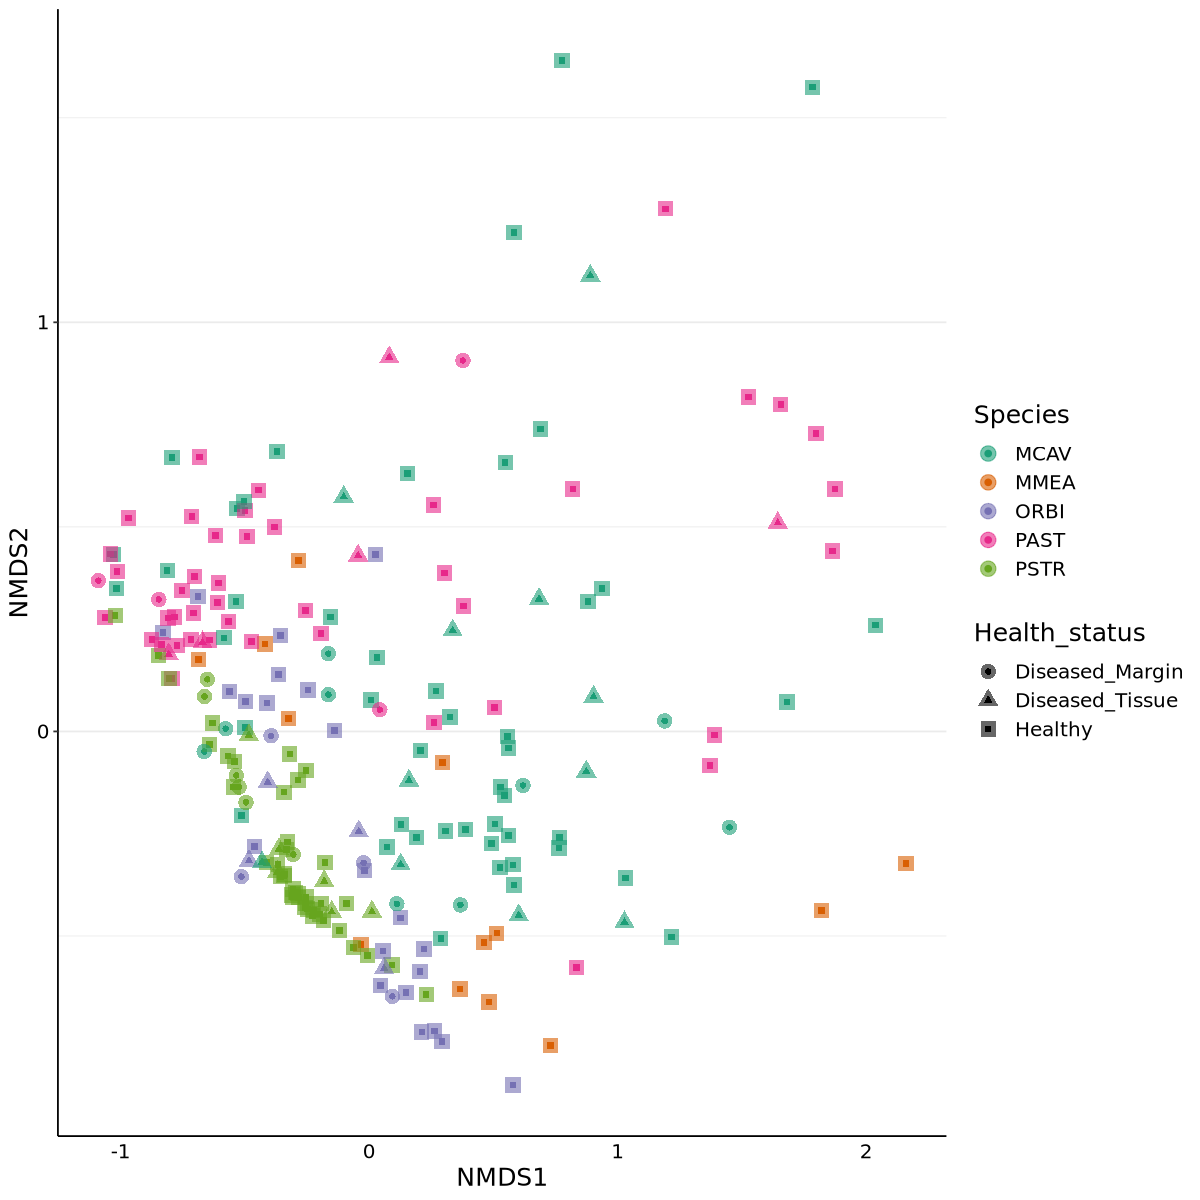

In [48]:
# visualize ordination plot
sctld_all_plot <- plot_ordination(sctld_all2, sctld_all2.ord, type="samples", color="Species", shape="Health_status")+
geom_point(size=4, alpha = 0.6) + 
scale_color_brewer(palette = "Dark2")+
# facet_wrap(
# geom_label(aes(label = sample_data(sctld_all2)$sampleid), vjust = -1, color = "black") +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
sctld_all_plot

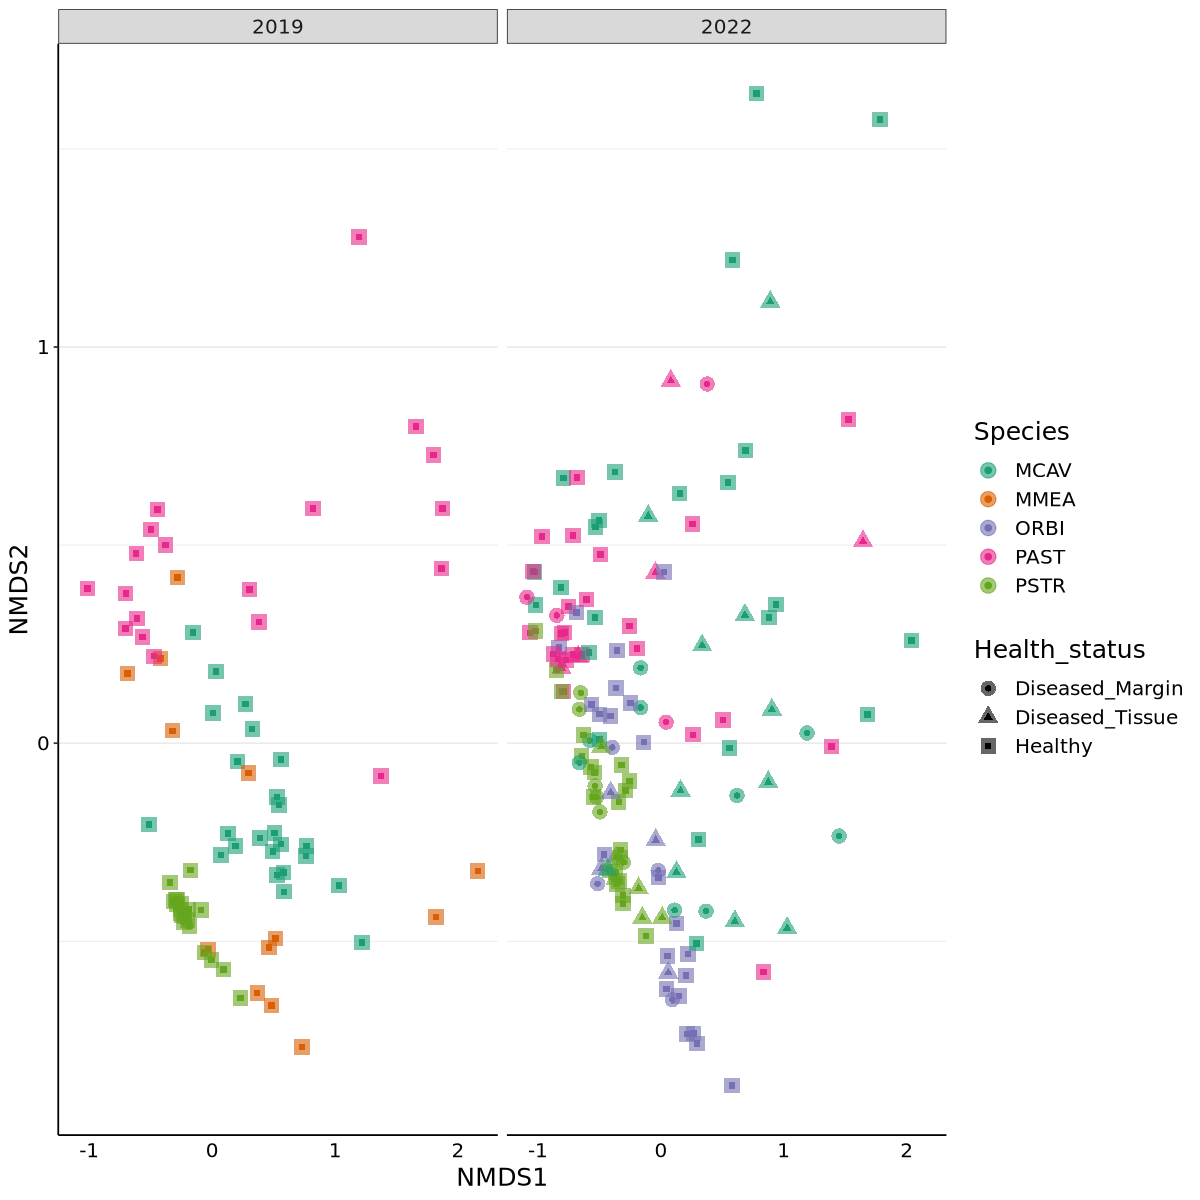

In [49]:
# facet by year
sctld_all_plot <- plot_ordination(sctld_all2, sctld_all2.ord, type="samples", color="Species", shape="Health_status")+
geom_point(size=4, alpha = 0.6) + 
scale_color_brewer(palette = "Dark2")+
facet_wrap(~year)+
# geom_label(aes(label = sample_data(sctld_all2)$sampleid), vjust = -1, color = "black") +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
sctld_all_plot

In [50]:
# outliers really causing issues - see previous commits to view 
# leaving filtered out for now??

In [51]:
# 2019 only - RS
RS_ps <- subset_samples(sctld_all2, year == "2019")
RS.ord <- ordinate(RS_ps, "NMDS", "bray", trymax=1000)

Square root transformation
Wisconsin double standardization
Run 0 stress 0.1074398 
Run 1 stress 0.1180725 
Run 2 stress 0.1074398 
... Procrustes: rmse 1.520633e-05  max resid 5.57788e-05 
... Similar to previous best
Run 3 stress 0.1141215 
Run 4 stress 0.1140513 
Run 5 stress 0.1060211 
... New best solution
... Procrustes: rmse 0.01086681  max resid 0.06010728 
Run 6 stress 0.1141126 
Run 7 stress 0.1180726 
Run 8 stress 0.1180726 
Run 9 stress 0.1343702 
Run 10 stress 0.1286786 
Run 11 stress 0.1135785 
Run 12 stress 0.1135785 
Run 13 stress 0.1180725 
Run 14 stress 0.1207801 
Run 15 stress 0.4090072 
Run 16 stress 0.1064491 
... Procrustes: rmse 0.006986836  max resid 0.05686469 
Run 17 stress 0.4093077 
Run 18 stress 0.1135786 
Run 19 stress 0.1064491 
... Procrustes: rmse 0.006986059  max resid 0.05685116 
Run 20 stress 0.1140513 
Run 21 stress 0.1074398 
Run 22 stress 0.1176493 
Run 23 stress 0.4093087 
Run 24 stress 0.1180725 
Run 25 stress 0.1060211 
... Procrustes: rmse 6.5

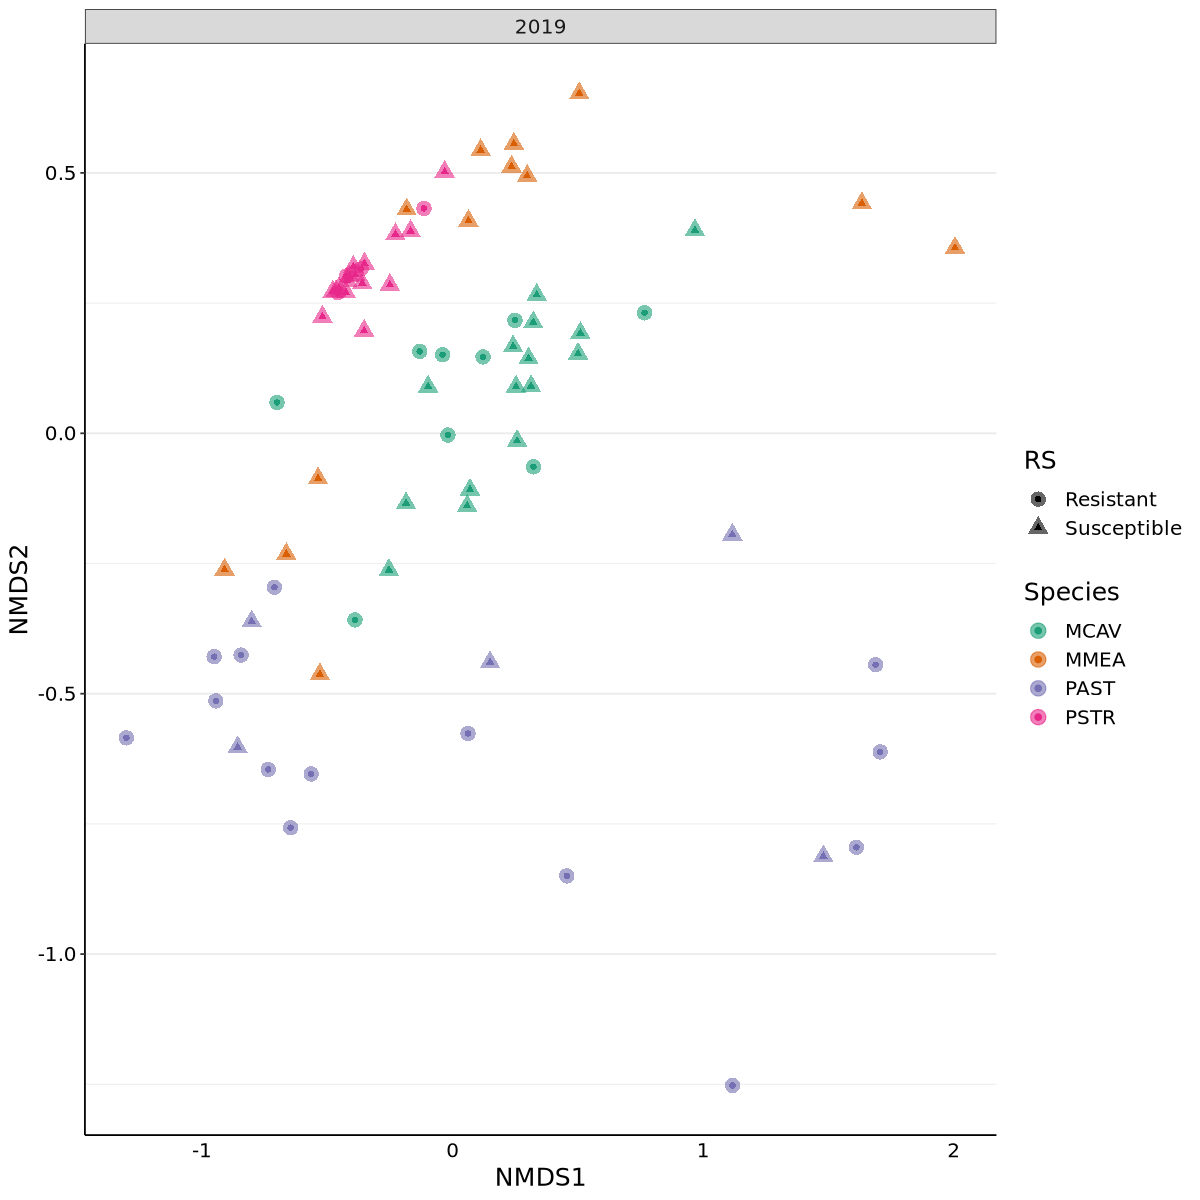

In [52]:
plot_ordination(RS_ps, RS.ord, type="samples", color="Species", shape="RS")+
geom_point(size=4, alpha = 0.6) + 
scale_color_brewer(palette = "Dark2")+
facet_wrap(~year)+
# geom_label(aes(label = sample_data(sctld_all2)$sampleid), vjust = -1, color = "black") +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))

In [53]:
# ggsave(filename = "taxonomy_species_nmds.png", plot = sctld_all_plot, 
#       width = 10,
#       height = 10,
#       units = "in",
#       dpi = 300)

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”
Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


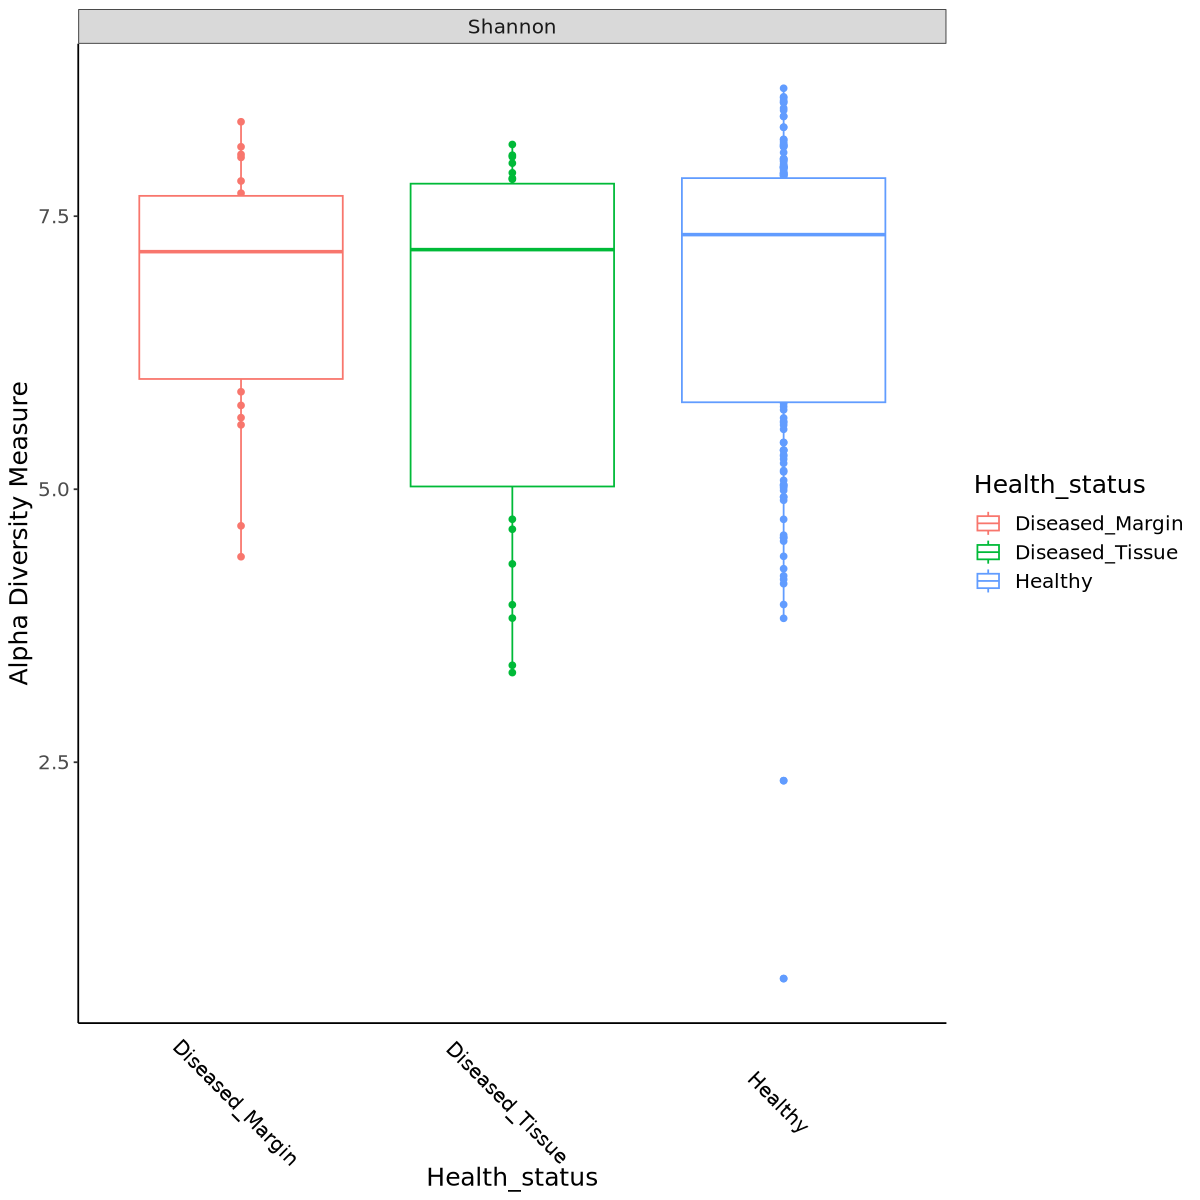

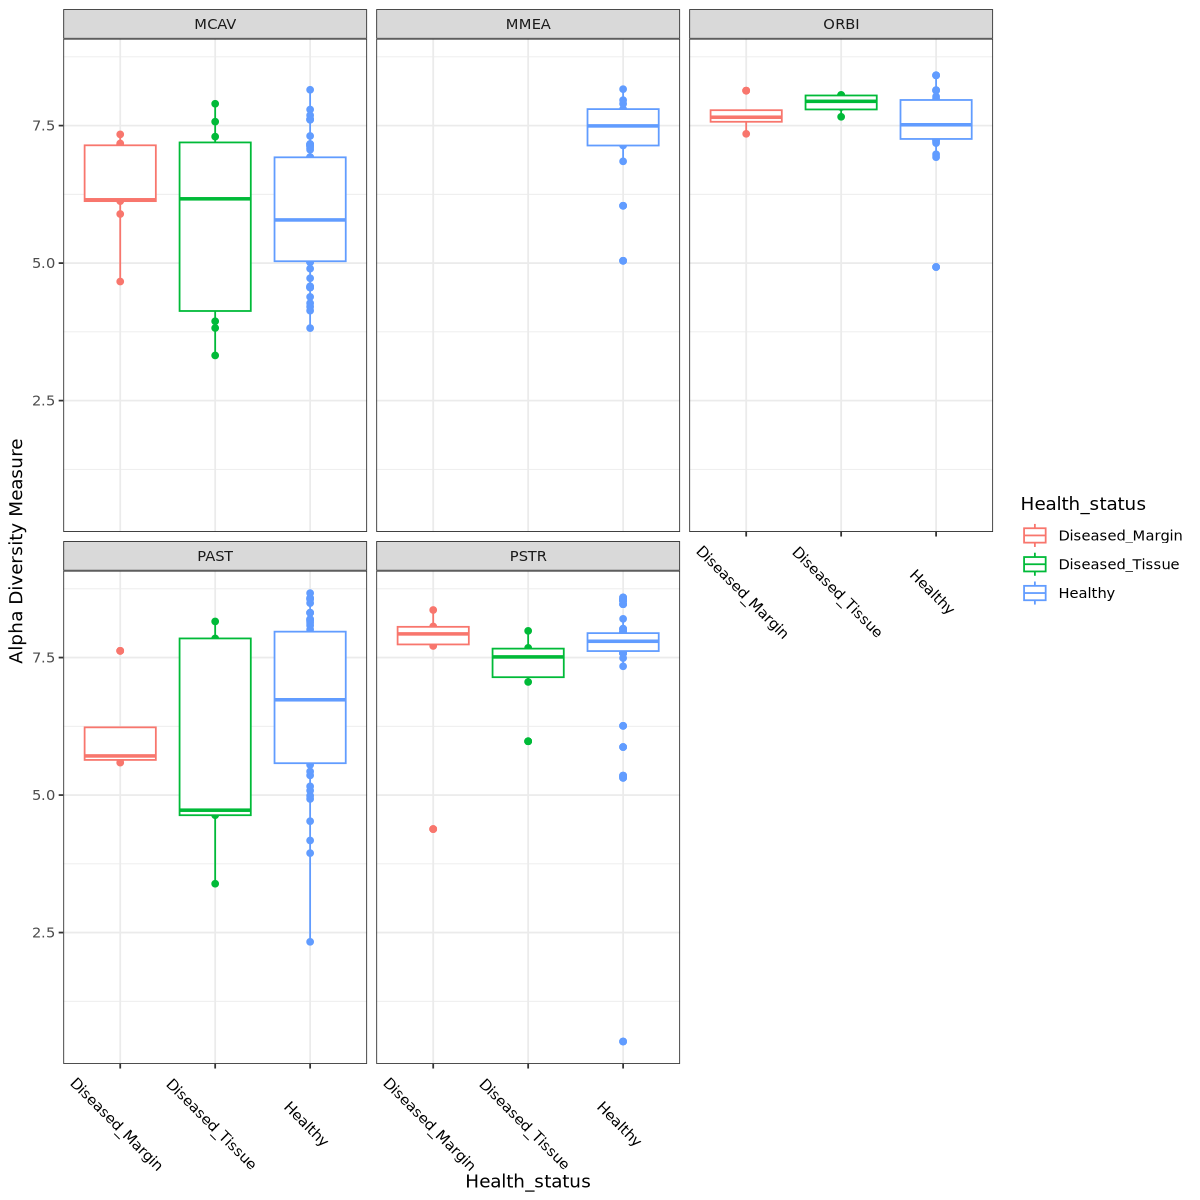

In [54]:
rich_status <- plot_richness(sctld_all, x="Health_status", color="Health_status", measures=c("Shannon")) + 
geom_boxplot() +
# facet_wrap(~Species)+
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(color = "black", angle = -45, hjust = 0.5),
    text = element_text(size = 15))
rich_status

plot_richness(sctld_all, x="Health_status", color="Health_status", measures=c("Shannon")) + 
geom_boxplot() +
facet_wrap(~Species)+
theme_bw()+
theme(axis.text.x = element_text(color = "black", angle = -45, hjust = 0.5))

In [55]:
# ggsave(filename = "shannon_richness_sample_type.png", plot = rich_status, 
#       width = 10,
#       height = 10,
#       units = "in",
#       dpi = 300)

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


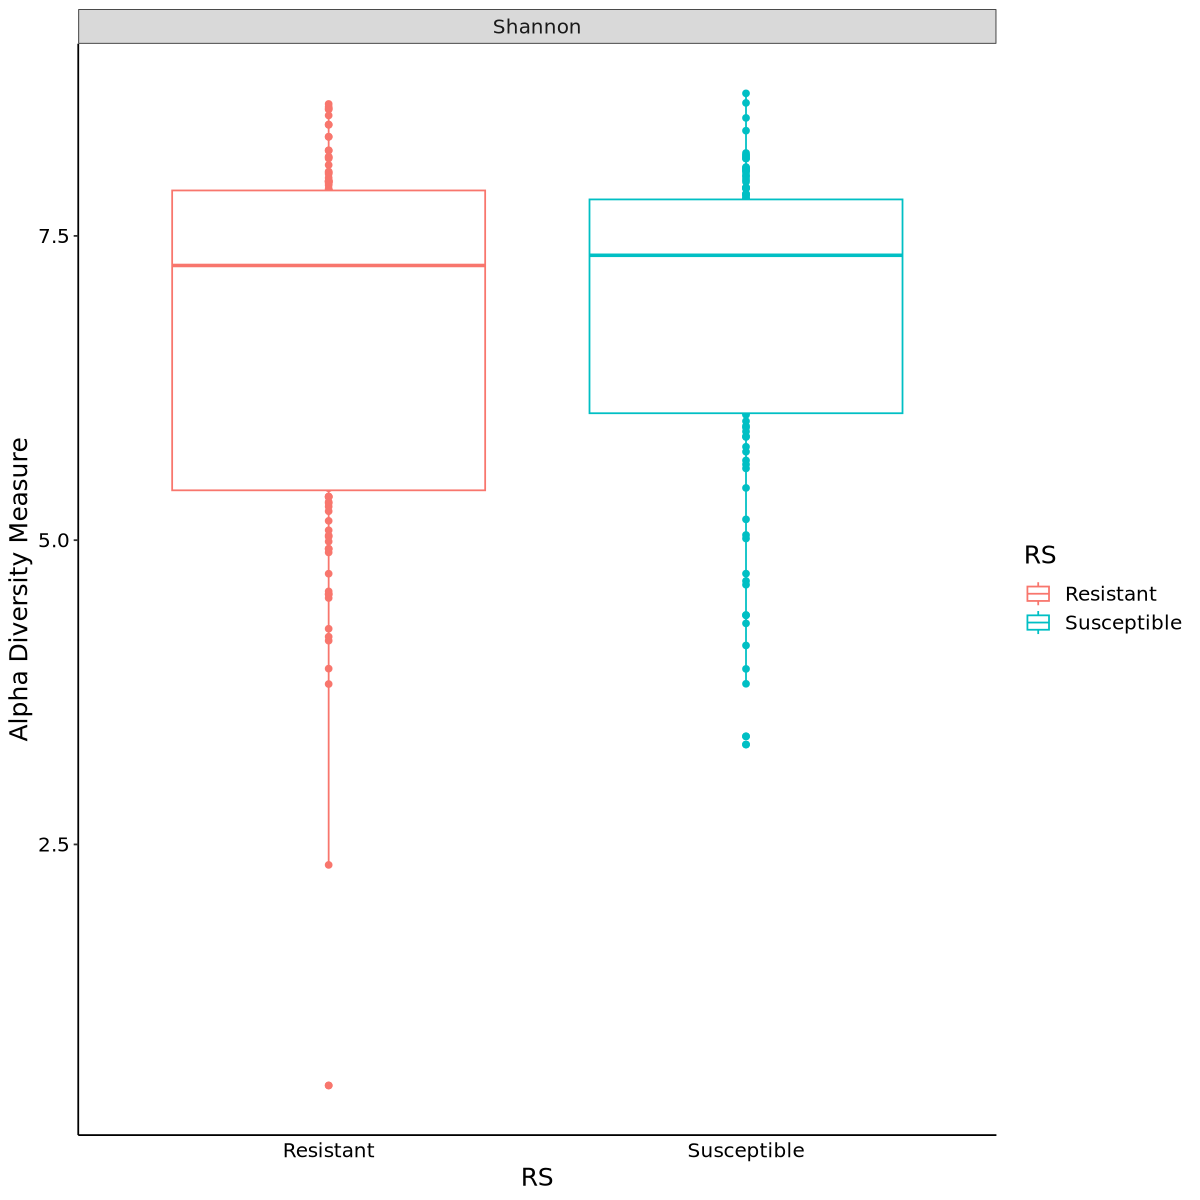

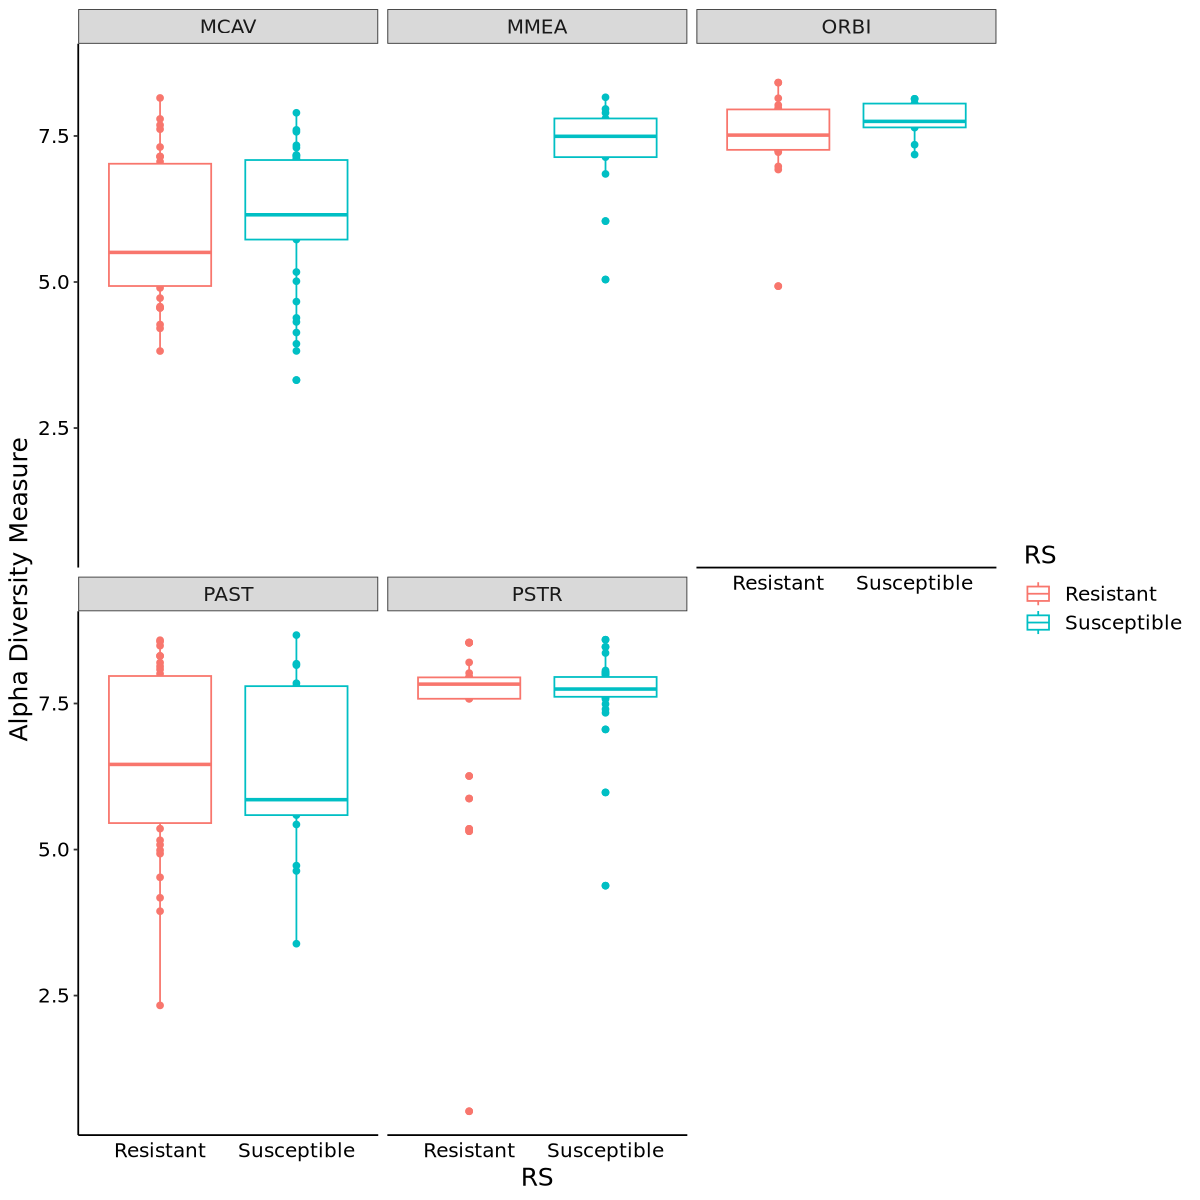

In [56]:
rich_status1 <- plot_richness(sctld_all, x="RS", color="RS", measures=c("Shannon")) + geom_boxplot() +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
rich_status1

rich_status1+
    facet_wrap(~Species)

In [57]:
# ggsave(filename = "shannon_richness_sctld_status.png", plot = rich_status1, 
#       width = 10,
#       height = 10,
#       units = "in",
#       dpi = 300)

In [58]:
options(repr.plot.width=15, repr.plot.height=10)

In [59]:
# rich_species <- plot_richness(sctld_all, x="Species", color="SCTLD_status", measures=c("Shannon")) + geom_point() +
# theme_bw()+
#  theme(legend.position = "right",
#     panel.border = element_blank(),
#     panel.grid.major.x = element_blank(),
#     panel.grid.minor.x = element_blank(),
#     axis.ticks.x = element_blank(),
#     axis.line = element_line(color = "black"),
#     axis.text = element_text(color = "black"),
#     text = element_text(size = 15))
# rich_species

In [60]:
# Calculate the Bray-Curtis distance matrix
bray_dist <- phyloseq::distance(sctld_all2, method = "bray")
metadata2 <- as(phyloseq::sample_data(sctld_all2), "data.frame")

In [61]:
permanova <- vegan::adonis2(bray_dist ~ RS * Species * year, data = metadata2, permutations = 999)
print(permanova)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ RS * Species * year, data = metadata2, permutations = 999)
                 Df SumOfSqs      R2       F Pr(>F)    
RS                1    1.041 0.02220  7.0723  0.001 ***
Species           4   13.229 0.28210 22.4722  0.001 ***
year              1    1.119 0.02386  7.6018  0.001 ***
RS:Species        3    0.523 0.01116  1.1849  0.259    
RS:year           1    0.126 0.00268  0.8529  0.466    
Species:year      2    1.118 0.02385  3.7992  0.002 ** 
RS:Species:year   2    0.305 0.00651  1.0374  0.407    
Residual        200   29.434 0.62766                   
Total           214   46.896 1.00000                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [62]:
# Specie explains 28% variation
# RS only 2% but is significant
# year also only 2% but is significant
# Species * year is significant factor - variation between years depending on the species

In [63]:
permanova2 <- vegan::adonis2(bray_dist ~ Health_status * RS * Species * year, data = metadata2, permutations = 999)
print(permanova2)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Species * year, data = metadata2, permutations = 999)
                       Df SumOfSqs      R2       F Pr(>F)    
Health_status           2    0.705 0.01503  2.4174  0.011 *  
RS                      1    1.238 0.02639  8.4912  0.001 ***
Species                 4   13.035 0.27796 22.3570  0.001 ***
year                    1    1.059 0.02258  7.2643  0.001 ***
Health_status:Species   6    0.954 0.02034  1.0908  0.327    
RS:Species              3    0.398 0.00849  0.9108  0.567    
RS:year                 1    0.157 0.00334  1.0741  0.296    
Species:year            2    1.229 0.02621  4.2157  0.001 ***
RS:Species:year         2    0.135 0.00287  0.4617  0.975    
Residual              192   27.987 0.59678                   
Total                 214   46.896 1.00000                   
---
Sign

In [64]:
# ok good adding health status shows similar results 
# health status is also significant effect (1.5% variation) 

In [65]:
permanova3 <- vegan::adonis2(bray_dist ~ Health_status * RS * Species * year * Transect, data = metadata2, permutations = 999)
print(permanova3)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Species * year * Transect, data = metadata2, permutations = 999)
                                Df SumOfSqs      R2       F Pr(>F)    
Health_status                    2    0.705 0.01503  2.5322  0.007 ** 
RS                               1    1.238 0.02639  8.8945  0.001 ***
Species                          4   13.035 0.27796 23.4189  0.001 ***
year                             1    1.059 0.02258  7.6094  0.001 ***
Transect                         3    0.902 0.01924  2.1616  0.006 ** 
Health_status:Species            6    0.995 0.02122  1.1916  0.206    
RS:Species                       3    0.392 0.00835  0.9382  0.513    
RS:year                          1    0.122 0.00261  0.8781  0.493    
Species:year                     2    1.178 0.02513  4.2340  0.001 ***
Health_status:Transect         

In [66]:
# location is more important than health status?

In [67]:
# within species, how much does RS explain difference

In [68]:
mcav_ps<- subset_samples(sctld_all2, Species == "MCAV")
bray_dist <- phyloseq::distance(mcav_ps, method = "bray")
mcav_meta <- as(phyloseq::sample_data(mcav_ps), "data.frame")
mcav_perma <- vegan::adonis2(bray_dist ~ Health_status * RS * year * Transect, data = mcav_meta, permutations = 999)
print(mcav_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * year * Transect, data = mcav_meta, permutations = 999)
                       Df SumOfSqs      R2      F Pr(>F)    
Health_status           2   0.6459 0.05430 2.0304  0.022 *  
RS                      1   0.2397 0.02015 1.5070  0.143    
year                    1   0.8914 0.07493 5.6044  0.001 ***
Transect                3   0.6066 0.05099 1.2712  0.189    
RS:year                 1   0.1360 0.01143 0.8552  0.497    
Health_status:Transect  4   0.6746 0.05671 1.0603  0.370    
RS:Transect             2   0.2818 0.02369 0.8859  0.545    
year:Transect           2   0.4674 0.03929 1.4692  0.103    
Residual               50   7.9527 0.66851                  
Total                  66  11.8960 1.00000                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [69]:
orbi_ps<- subset_samples(sctld_all2, Species == "ORBI")
bray_dist <- phyloseq::distance(orbi_ps, method = "bray")
orbi_meta <- as(phyloseq::sample_data(orbi_ps), "data.frame")
orbi_perma <- vegan::adonis2(bray_dist ~ Health_status * RS * Transect, data = orbi_meta, permutations = 999)
print(orbi_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Transect, data = orbi_meta, permutations = 999)
                       Df SumOfSqs      R2      F Pr(>F)
Health_status           2   0.2728 0.07340 1.0707  0.357
RS                      1   0.0737 0.01984 0.5789  0.793
Transect                3   0.5362 0.14428 1.4031  0.105
Health_status:Transect  4   0.3831 0.10309 0.7519  0.777
RS:Transect             1   0.1575 0.04237 1.2362  0.267
Residual               18   2.2931 0.61701              
Total                  29   3.7165 1.00000              


In [70]:
# maybe we do need to separate out orbi species...

### DESeq2 R vs S 2019

In [71]:
#run DESeq2 on 2019 R vs S across species
## ALL SPECIES TOGETHER

ds_all = phyloseq_to_deseq2(RS_ps, ~ RS)
ds_all = DESeq(ds_all, test="Wald", fitType="parametric")
res = results(ds_all, cooksCutoff = FALSE, contrast=c("RS", "Resistant", "Susceptible"))
alpha = 0.00001
sigtab_a = res[which(res$padj < alpha), ]
sigtab_all = cbind(as(sigtab_a, "data.frame"), as(tax_table(RS_ps)[rownames(sigtab_a), ], "matrix"))
res
head(sigtab_all)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 3587 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



log2 fold change (MLE): RS Resistant vs Susceptible 
Wald test p-value: RS Resistant vs Susceptible 
DataFrame with 15891 rows and 6 columns
         baseMean log2FoldChange     lfcSE      stat      pvalue       padj
        <numeric>      <numeric> <numeric> <numeric>   <numeric>  <numeric>
2057741  161123.7       2.169737  0.597418   3.63186 0.000281390 0.00766557
1747      91088.8       1.698840  0.719387   2.36151 0.018200643 0.09525376
2066072   12536.1      -0.591030  0.379145  -1.55885 0.119031671 0.25258905
1929291    1621.0       0.898512  0.619740   1.44982 0.147108221 0.28376831
1325120   30993.1       2.285501  0.630405   3.62545 0.000288462 0.00771416
...           ...            ...       ...       ...         ...        ...
1788452         0             NA        NA        NA          NA         NA
2955573         0             NA        NA        NA          NA         NA
3060634         0             NA        NA        NA          NA         NA
1923618         0      

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
3101276,1011.3266,3.778886,0.6734466,5.611263,2.008548e-08,5.064411e-06,Candidatus Poriferisocius sp.
218144,1258.8208,-5.856205,0.9118021,-6.422671,1.339041e-10,4.726815e-08,Vagococcus carniphilus
5665,539.7162,1.824219,0.2867806,6.361027,2.004097e-10,5.895385e-08,Leishmania mexicana
2866200,973.4573,30.000000,3.0284860,9.905940,3.922646e-23,3.461735e-20,Bradyrhizobium sp. ISRA464
2866199,157.3748,29.425044,3.0285686,9.715826,2.581484e-22,1.518773e-19,Bradyrhizobium sp. ISRA463
2986766,134.0194,29.202357,3.0285858,9.642242,5.301722e-22,2.339385e-19,Delftia sp. UGAL515B_04


In [72]:
# sort by most significant 
sorted_sigtab_all <- sigtab_all %>%
  arrange(padj)
head(sorted_sigtab_all)
dim(sorted_sigtab_all)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
362,114.4831,28.943223,2.8289275,10.231165,1.437796e-24,2.537709e-21,Agrobacterium radiobacter
2866200,973.4573,30.000000,3.0284860,9.905940,3.922646e-23,3.461735e-20,Bradyrhizobium sp. ISRA464
2866199,157.3748,29.425044,3.0285686,9.715826,2.581484e-22,1.518773e-19,Bradyrhizobium sp. ISRA463
2986766,134.0194,29.202357,3.0285858,9.642242,5.301722e-22,2.339385e-19,Delftia sp. UGAL515B_04
218144,1258.8208,-5.856205,0.9118021,-6.422671,1.339041e-10,4.726815e-08,Vagococcus carniphilus
5665,539.7162,1.824219,0.2867806,6.361027,2.004097e-10,5.895385e-08,Leishmania mexicana


[1] 7 7

In [73]:
# add R vs S col
sigdiff_otus<-sorted_sigtab_all %>%
    mutate(RS = if_else(log2FoldChange<0, "Susceptible","Resistant"))

In [74]:
# export sig diff taxa
# write.csv(sorted_sigtab_all, file=".csv")

In [75]:
options(repr.plot.width=15, repr.plot.height=15)

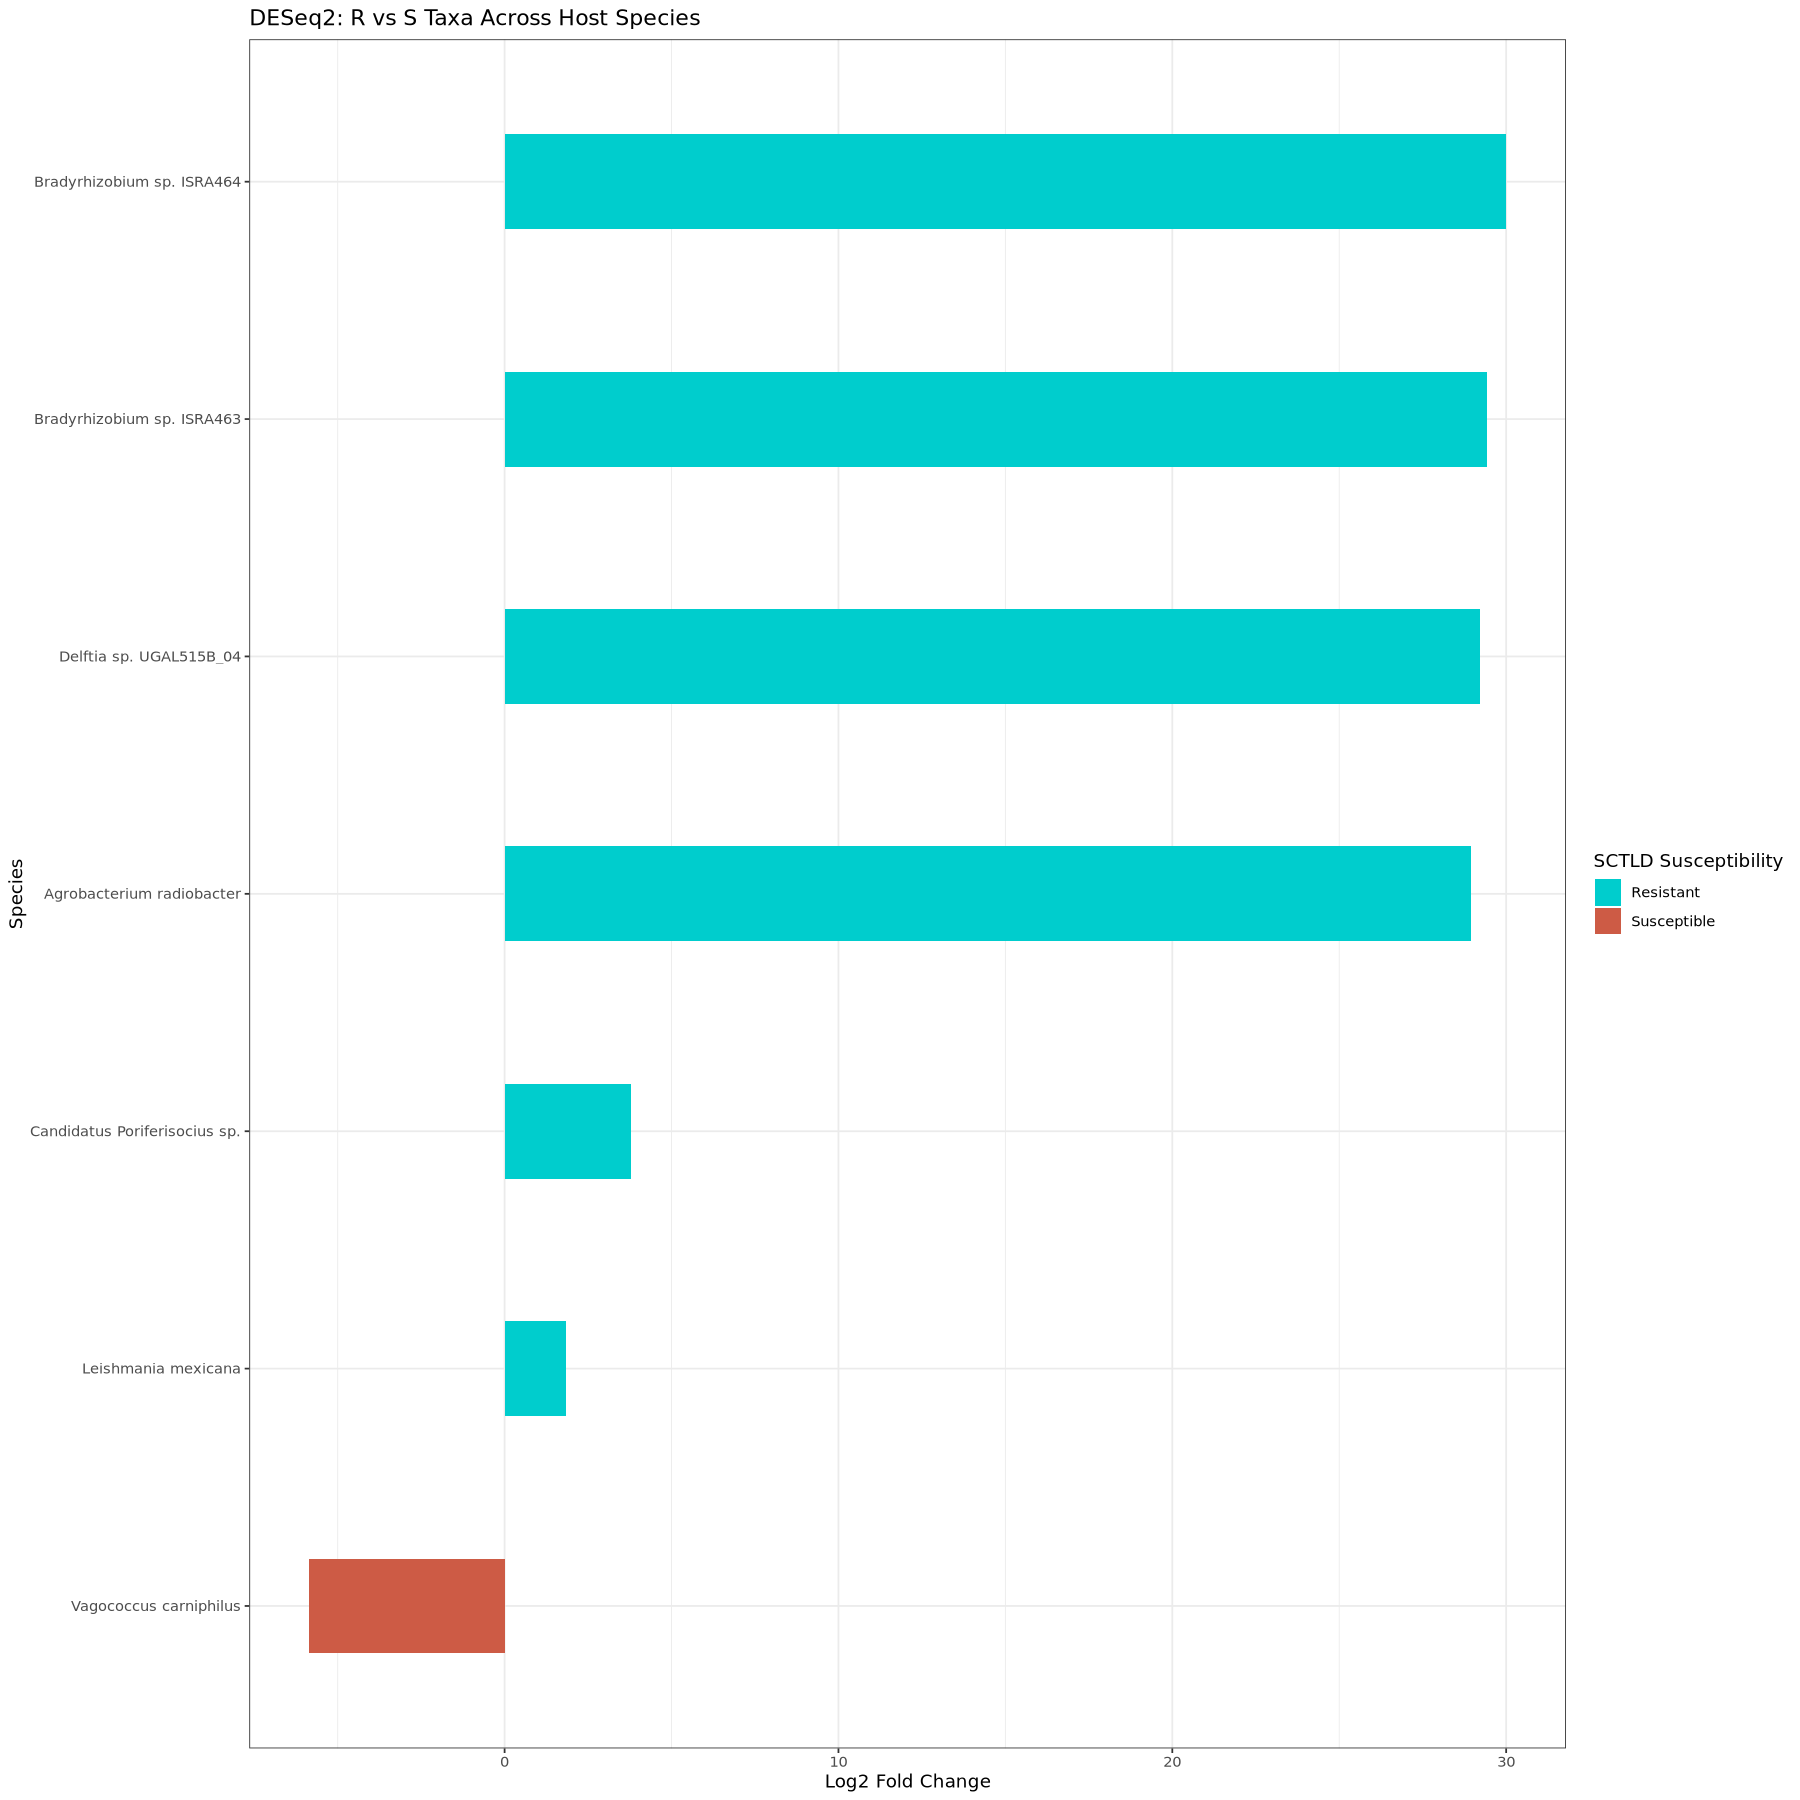

In [76]:
# plot significantly different OTUs 
ggplot(sigdiff_otus, aes(x = reorder(species,log2FoldChange), y = log2FoldChange, fill = RS)) +
    geom_bar(stat = "identity", width = 0.4) +
    coord_flip() + 
    scale_fill_manual(values= c("Resistant"="cyan3", "Susceptible"="coral3"))+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: R vs S Taxa Across Host Species", fill = "SCTLD Susceptibility")


In [77]:
# ggsave(filename = "DR_top_lfc_all_plot_HvDM_res.png", plot = top_lfc_all_plot, 
#       width = 10,
#       height = 15,
#       units = "in",
#       dpi = 300)

#### MCAV

In [78]:
#run DESeq2 on MCAV
mcav_ps<- subset_samples(RS_ps, Species == "MCAV")

mcav_rs = phyloseq_to_deseq2(mcav_ps, ~ RS)
mcav_rs = DESeq(mcav_rs, test="Wald", fitType="parametric")
res = results(mcav_rs, cooksCutoff = FALSE, contrast=c("RS", "Resistant", "Susceptible"))
alpha = 0.00001
sigtab_a = res[which(res$padj < alpha), ]
sigtab_mcav = cbind(as(sigtab_a, "data.frame"), as(tax_table(mcav_ps)[rownames(sigtab_a), ], "matrix"))

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 3949 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



In [79]:
# sort by most significant 
sigtab_mcav <- sigtab_mcav %>%
  arrange(padj)%>%
# add R vs S col
    mutate(RS = if_else(log2FoldChange<0, "Susceptible","Resistant"))
head(sigtab_mcav)
dim(sigtab_mcav)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species,RS
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
3017782,28.74736,25.15221,2.579217,9.751877,1.810893e-22,1.784092e-18,Paracoccus sp. SCSIO 75233,Resistant
2986766,163.33433,27.52578,3.026311,9.095490,9.416062e-20,4.638352e-16,Delftia sp. UGAL515B_04,Resistant
2866199,45.07630,25.76205,3.026641,8.511763,1.713077e-17,5.625746e-14,Bradyrhizobium sp. ISRA463,Resistant
2921645,20.30058,24.67890,2.925933,8.434541,3.325051e-17,8.189600e-14,Paenibacillus sp. FSL R5-0486,Resistant
51101,19.52443,24.59053,2.927398,8.400132,4.459752e-17,8.787495e-14,Brevibacillus agri,Resistant
3127471,18.30699,24.50271,2.959120,8.280403,1.227589e-16,1.750897e-13,Bernardetia sp. Wsw4-3y2,Resistant


[1] 32  8

In [80]:
options(repr.plot.height = 15, repr.plot.width = 15)

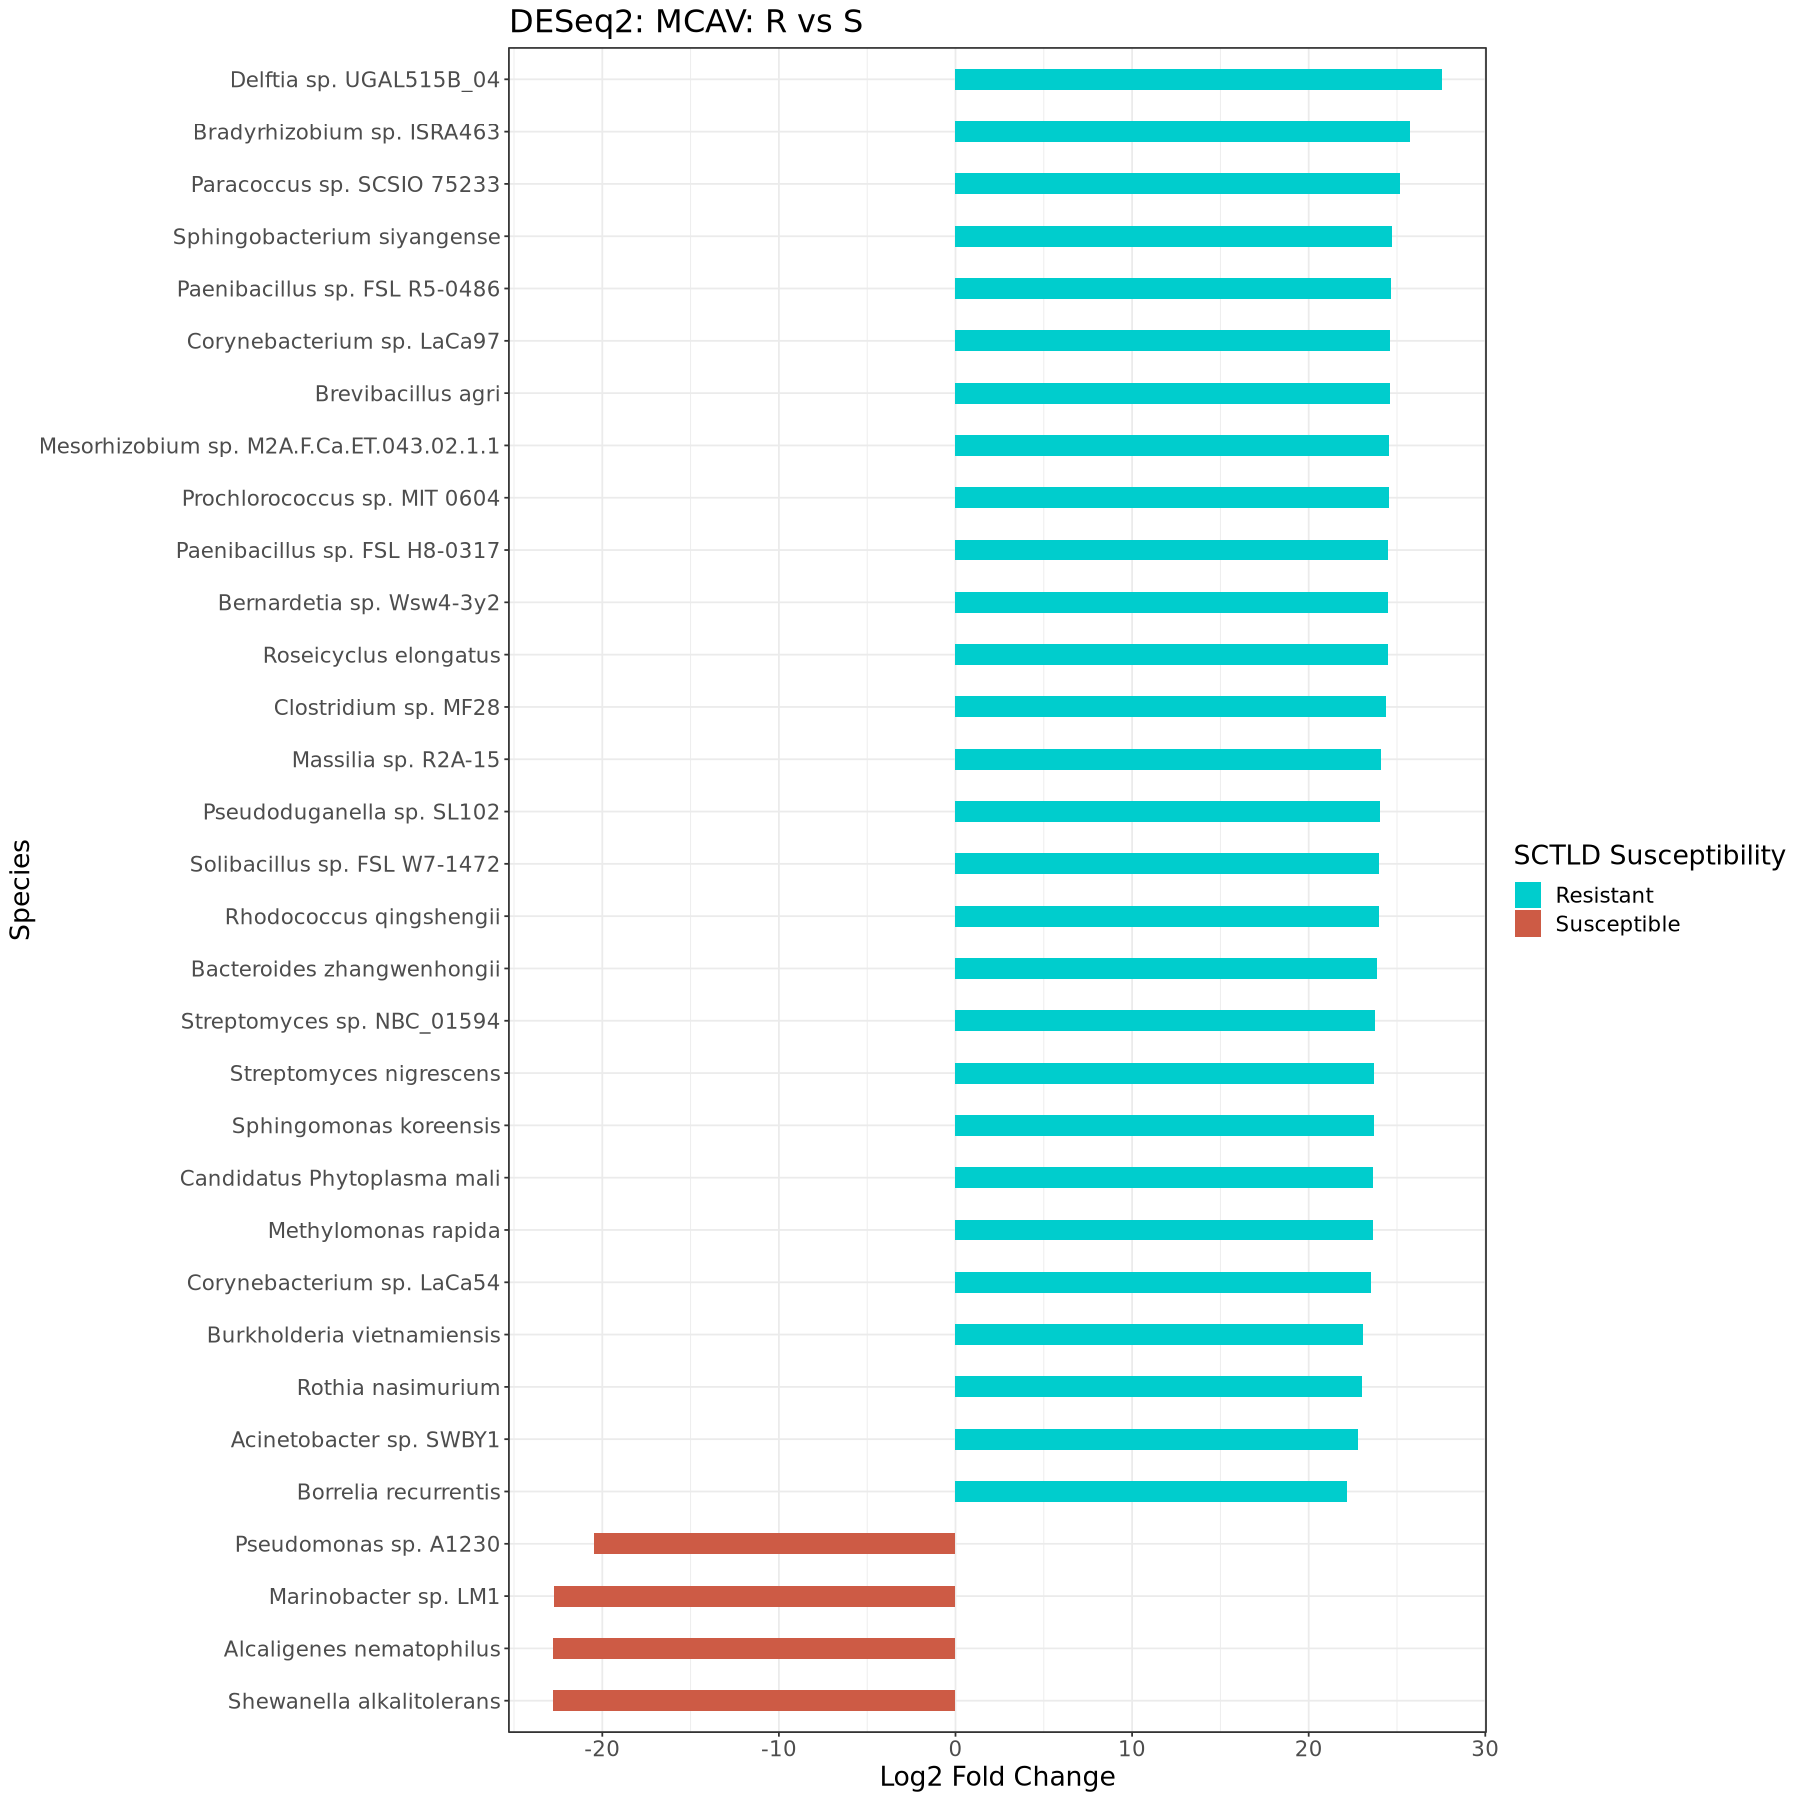

In [81]:
# plot significantly different OTUs 
ggplot(sigtab_mcav, aes(x = reorder(species,log2FoldChange), y = log2FoldChange, fill = RS)) +
    geom_bar(stat = "identity", width = 0.4) +
    coord_flip() + 
    scale_fill_manual(values= c("Resistant"="cyan3", "Susceptible"="coral3"))+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: MCAV: R vs S", fill = "SCTLD Susceptibility")+
    theme(text = element_text(size = 16)) 


#### PSTR

In [91]:
pstr_ps<- subset_samples(RS_ps, Species == "PSTR")

pstr_ds<-run_deseq(pstr_ps, "RS","Resistant","Susceptible")

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 2415 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



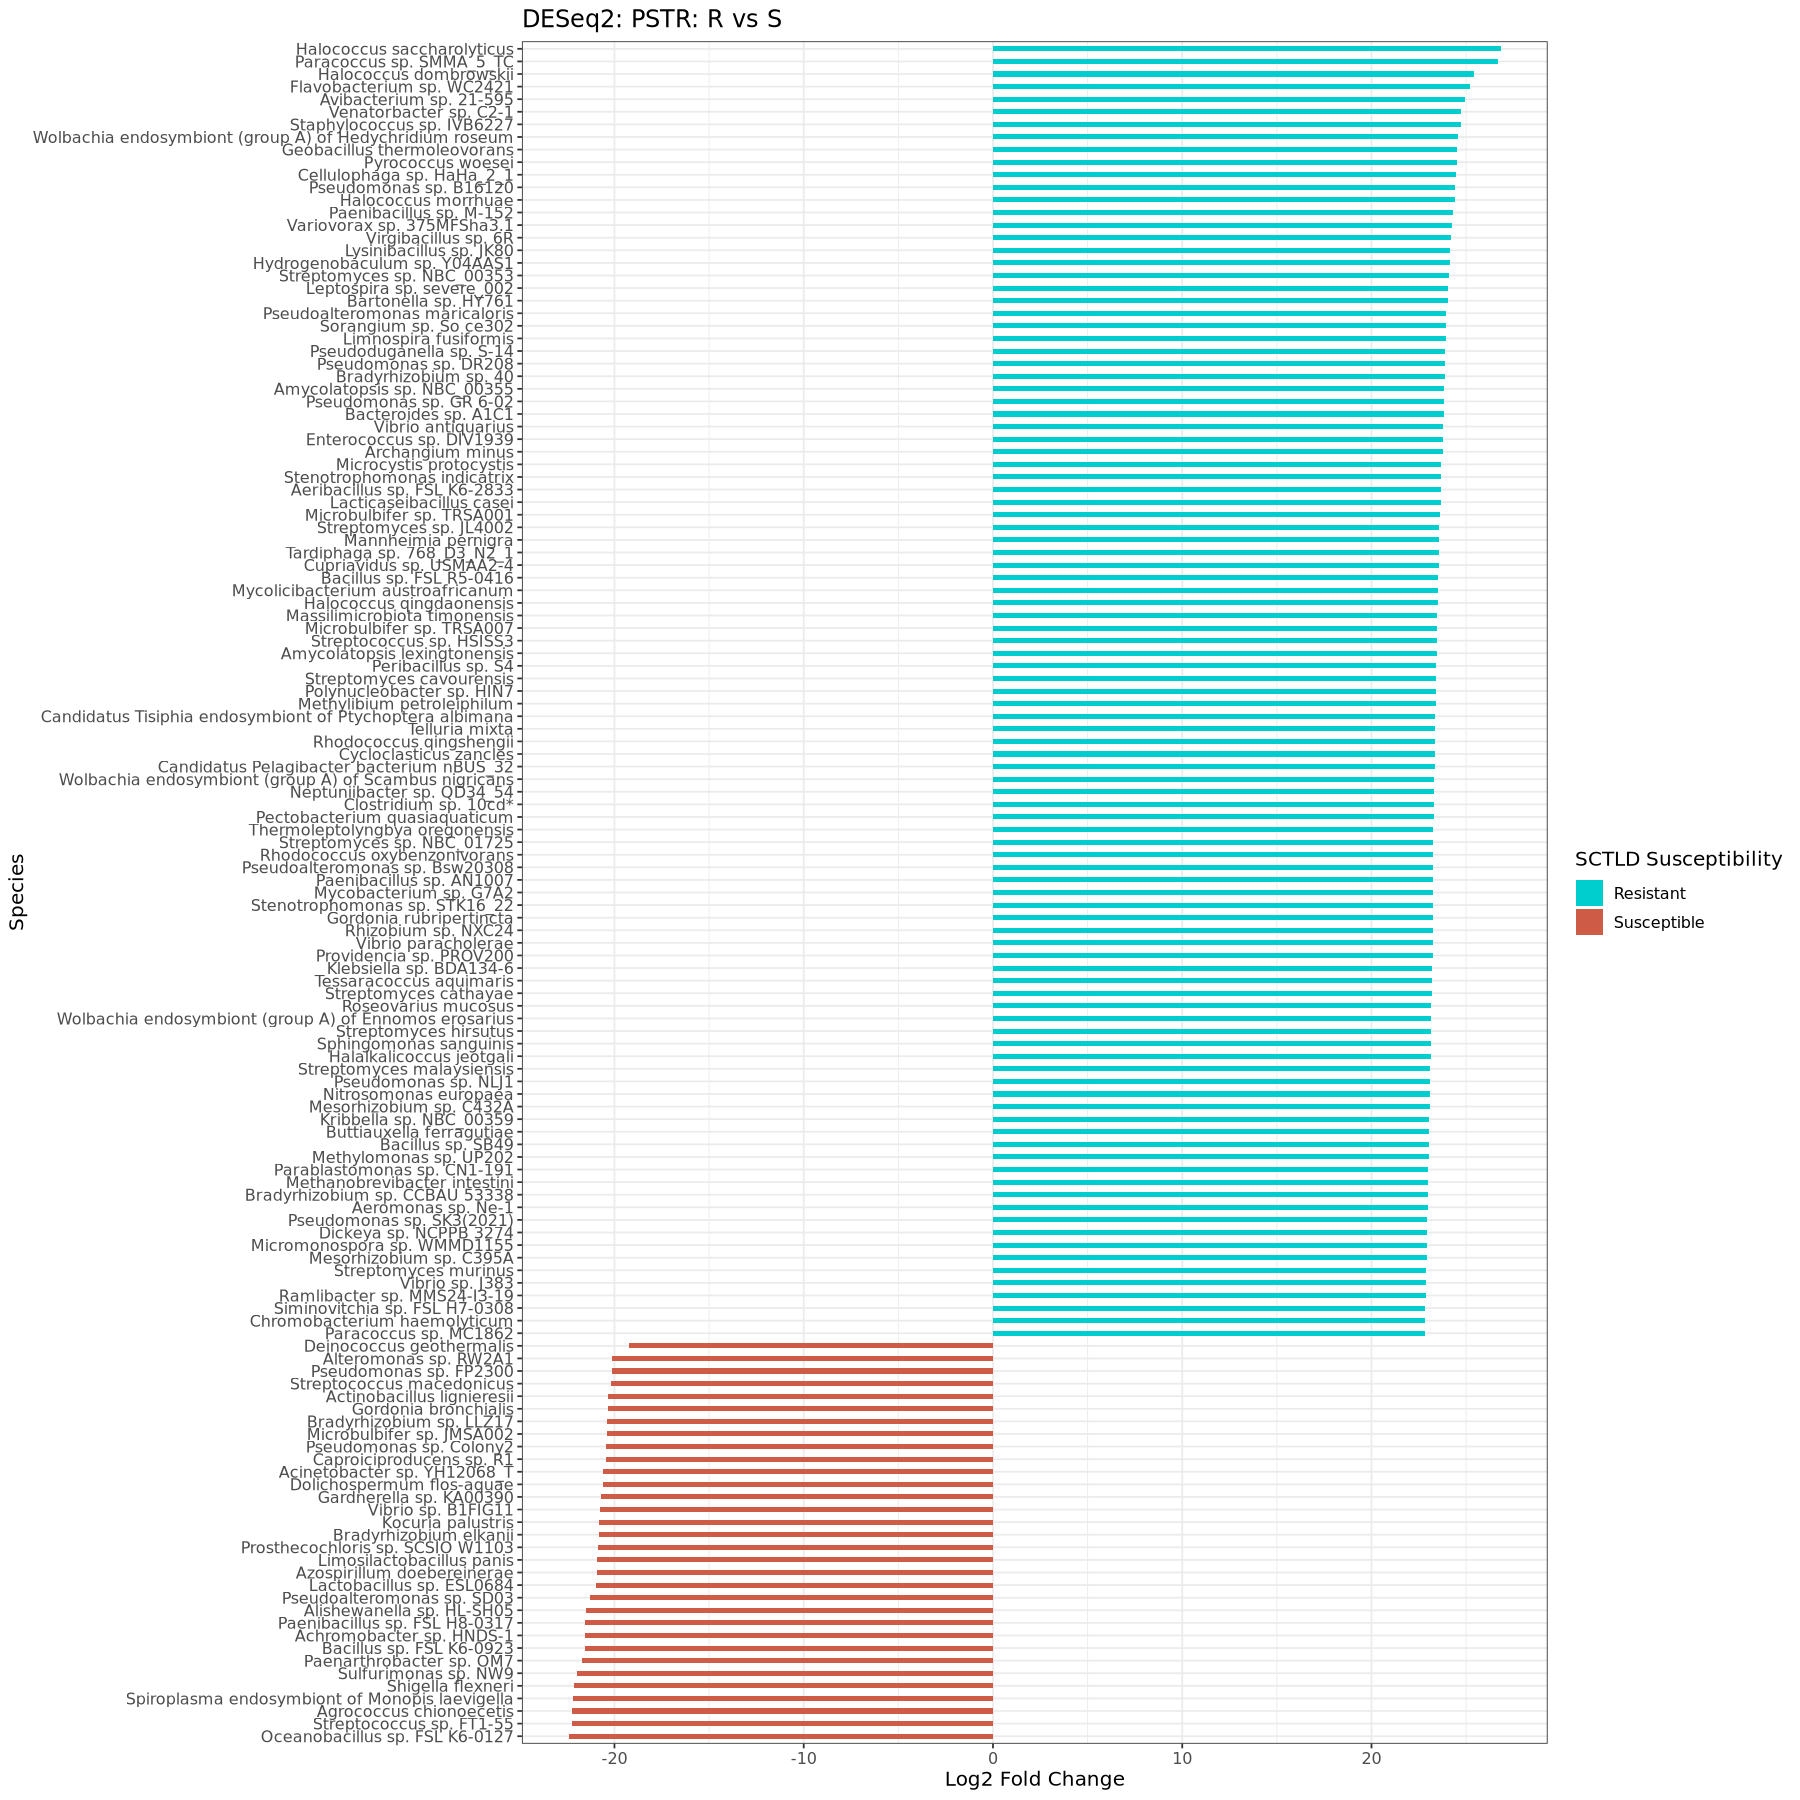

In [95]:
pstr_res<-view_ds_res(pstr_ds, "RS","Resistant","Susceptible")

# plot significantly different OTUs 
ggplot(pstr_res, aes(x = reorder(species,log2FoldChange), y = log2FoldChange, fill = RS)) +
    geom_bar(stat = "identity", width = 0.4) +
    coord_flip() + 
    scale_fill_manual(values= c("Resistant"="cyan3", "Susceptible"="coral3"))+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: PSTR: R vs S", fill = "SCTLD Susceptibility")+
    theme(text = element_text(size = 12)) 

In [ ]:
# do orbis 2022 healthy and diseased tissue r vs s??

In [ ]:
# do mmea healthy (sus) vs all other resis spp? 

### DESeq2 Disease vs Healthy

In [82]:
# make phyloseq fxn
run_deseq <- function(phylo_obj, comparison, contrast1, contrast2){
    ds_formula <- as.formula(paste0("~ ", comparison))
    ps_ds = phyloseq_to_deseq2(phylo_obj, ds_formula)
    
    for_ds = DESeq(ps_ds, test="Wald", fitType="parametric")
    res = results(for_ds, cooksCutoff = FALSE, contrast=c(comparison, contrast1, contrast2))
    alpha = 0.00001
    sigtab_a = res[which(res$padj < alpha), ]
    sigtab_all = cbind(as(sigtab_a, "data.frame"), as(tax_table(phylo_obj)[rownames(sigtab_a), ], "matrix"))
    return(sigtab_all)
    }

view_ds_res<-function(sigtab_all, comparison,contrast1, contrast2){
    sigtab_res <- sigtab_all %>%
        arrange(padj)%>%
    # add contrast cols
        mutate(!!sym(comparison):= if_else(log2FoldChange<0, contrast2,contrast1))
    return(sigtab_res)
    }

In [83]:
# all specie comparisons: healthy vs disease
dis_all_ds = phyloseq_to_deseq2(sctld_all2, ~ Health_status)
dis_all_ds = DESeq(dis_all_ds, test="Wald", fitType="parametric")
res = results(dis_all_ds, cooksCutoff = FALSE, contrast=c("Health_status", "Healthy", "Diseased_Margin"))
alpha = 0.00001
sigtab_a = res[which(res$padj < alpha), ]
sigtab_mcav = cbind(as(sigtab_a, "data.frame"), as(tax_table(sctld_all2)[rownames(sigtab_a), ], "matrix"))

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 6061 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



In [84]:
# sort by most significant 
sigtab_hs <- sigtab_mcav %>%
  arrange(padj)%>%
# add R vs S col
    mutate(HS = if_else(log2FoldChange<0, "Diseased_Margin","Healthy"))
head(sigtab_hs)
dim(sigtab_hs)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species,HS
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2321133,426.63856,-3.167563,0.2552711,-12.408622,2.346559e-35,1.847680e-31,Halarcobacter sp.,Diseased_Margin
2829569,486.83372,-5.774577,0.5064757,-11.401489,4.110287e-30,1.618220e-26,Bacterioplanoides sp. SCSIO 12839,Diseased_Margin
2903816,36.80971,23.652105,2.4100674,9.813877,9.812461e-23,2.575444e-19,Streptomyces sp. NBC_01296,Healthy
199592,61.85892,25.162637,2.6347652,9.550239,1.293975e-21,2.547190e-18,Microbacterium paraoxydans,Healthy
3021011,975.98421,-6.539076,0.7560531,-8.648964,5.196889e-18,8.184061e-15,Vibrio sp. SCSIO 43137,Diseased_Margin
1462615,219.38222,-3.390348,0.4174183,-8.122183,4.578713e-16,6.008798e-13,Halarcobacter ebronensis,Diseased_Margin


[1] 21  8

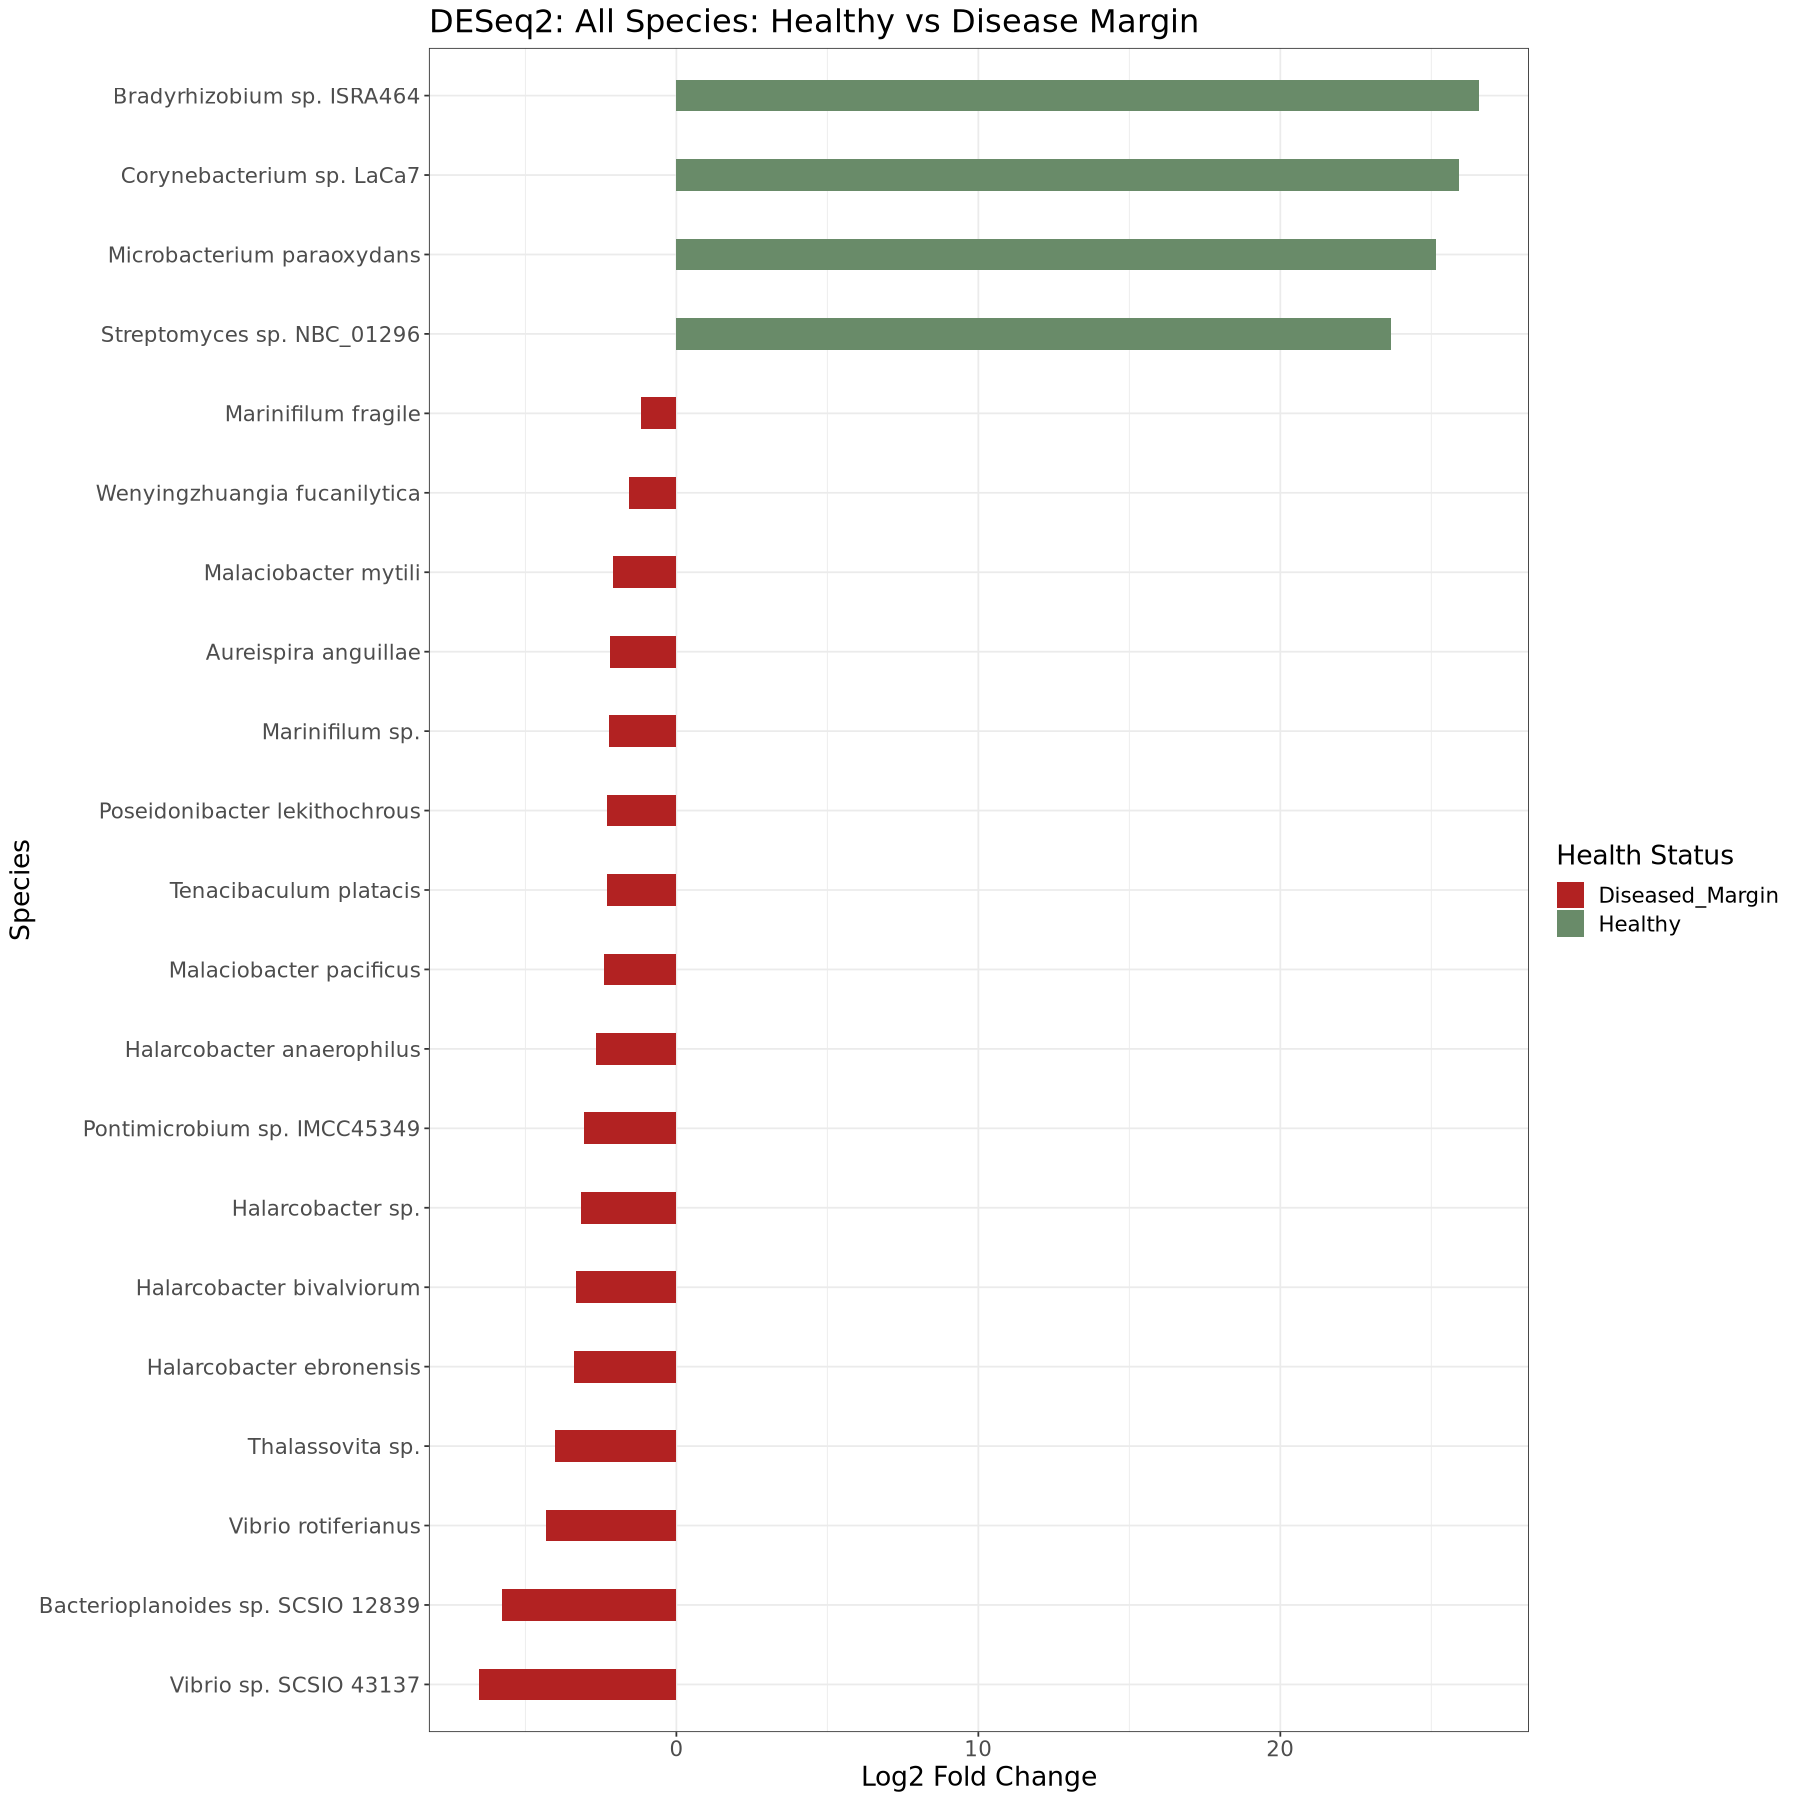

In [85]:
# plot significantly different OTUs
ggplot(sigtab_hs, aes(x = reorder(species,log2FoldChange), y = log2FoldChange, fill = HS)) +
    geom_bar(stat = "identity", width = 0.4) +
    coord_flip() + 
    scale_fill_manual(values= c("Healthy"="darkseagreen4", "Diseased_Margin"="firebrick"))+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: All Species: Healthy vs Disease Margin", fill = "Health Status")+
    theme(text = element_text(size = 16)) 

In [86]:
# disease margin vs disease tissue
dm_dt_ds<-run_deseq(phylo_obj = sctld_all2, comparison = "Health_status", contrast1 = "Diseased_Tissue",contrast2 = "Diseased_Margin")

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 6061 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



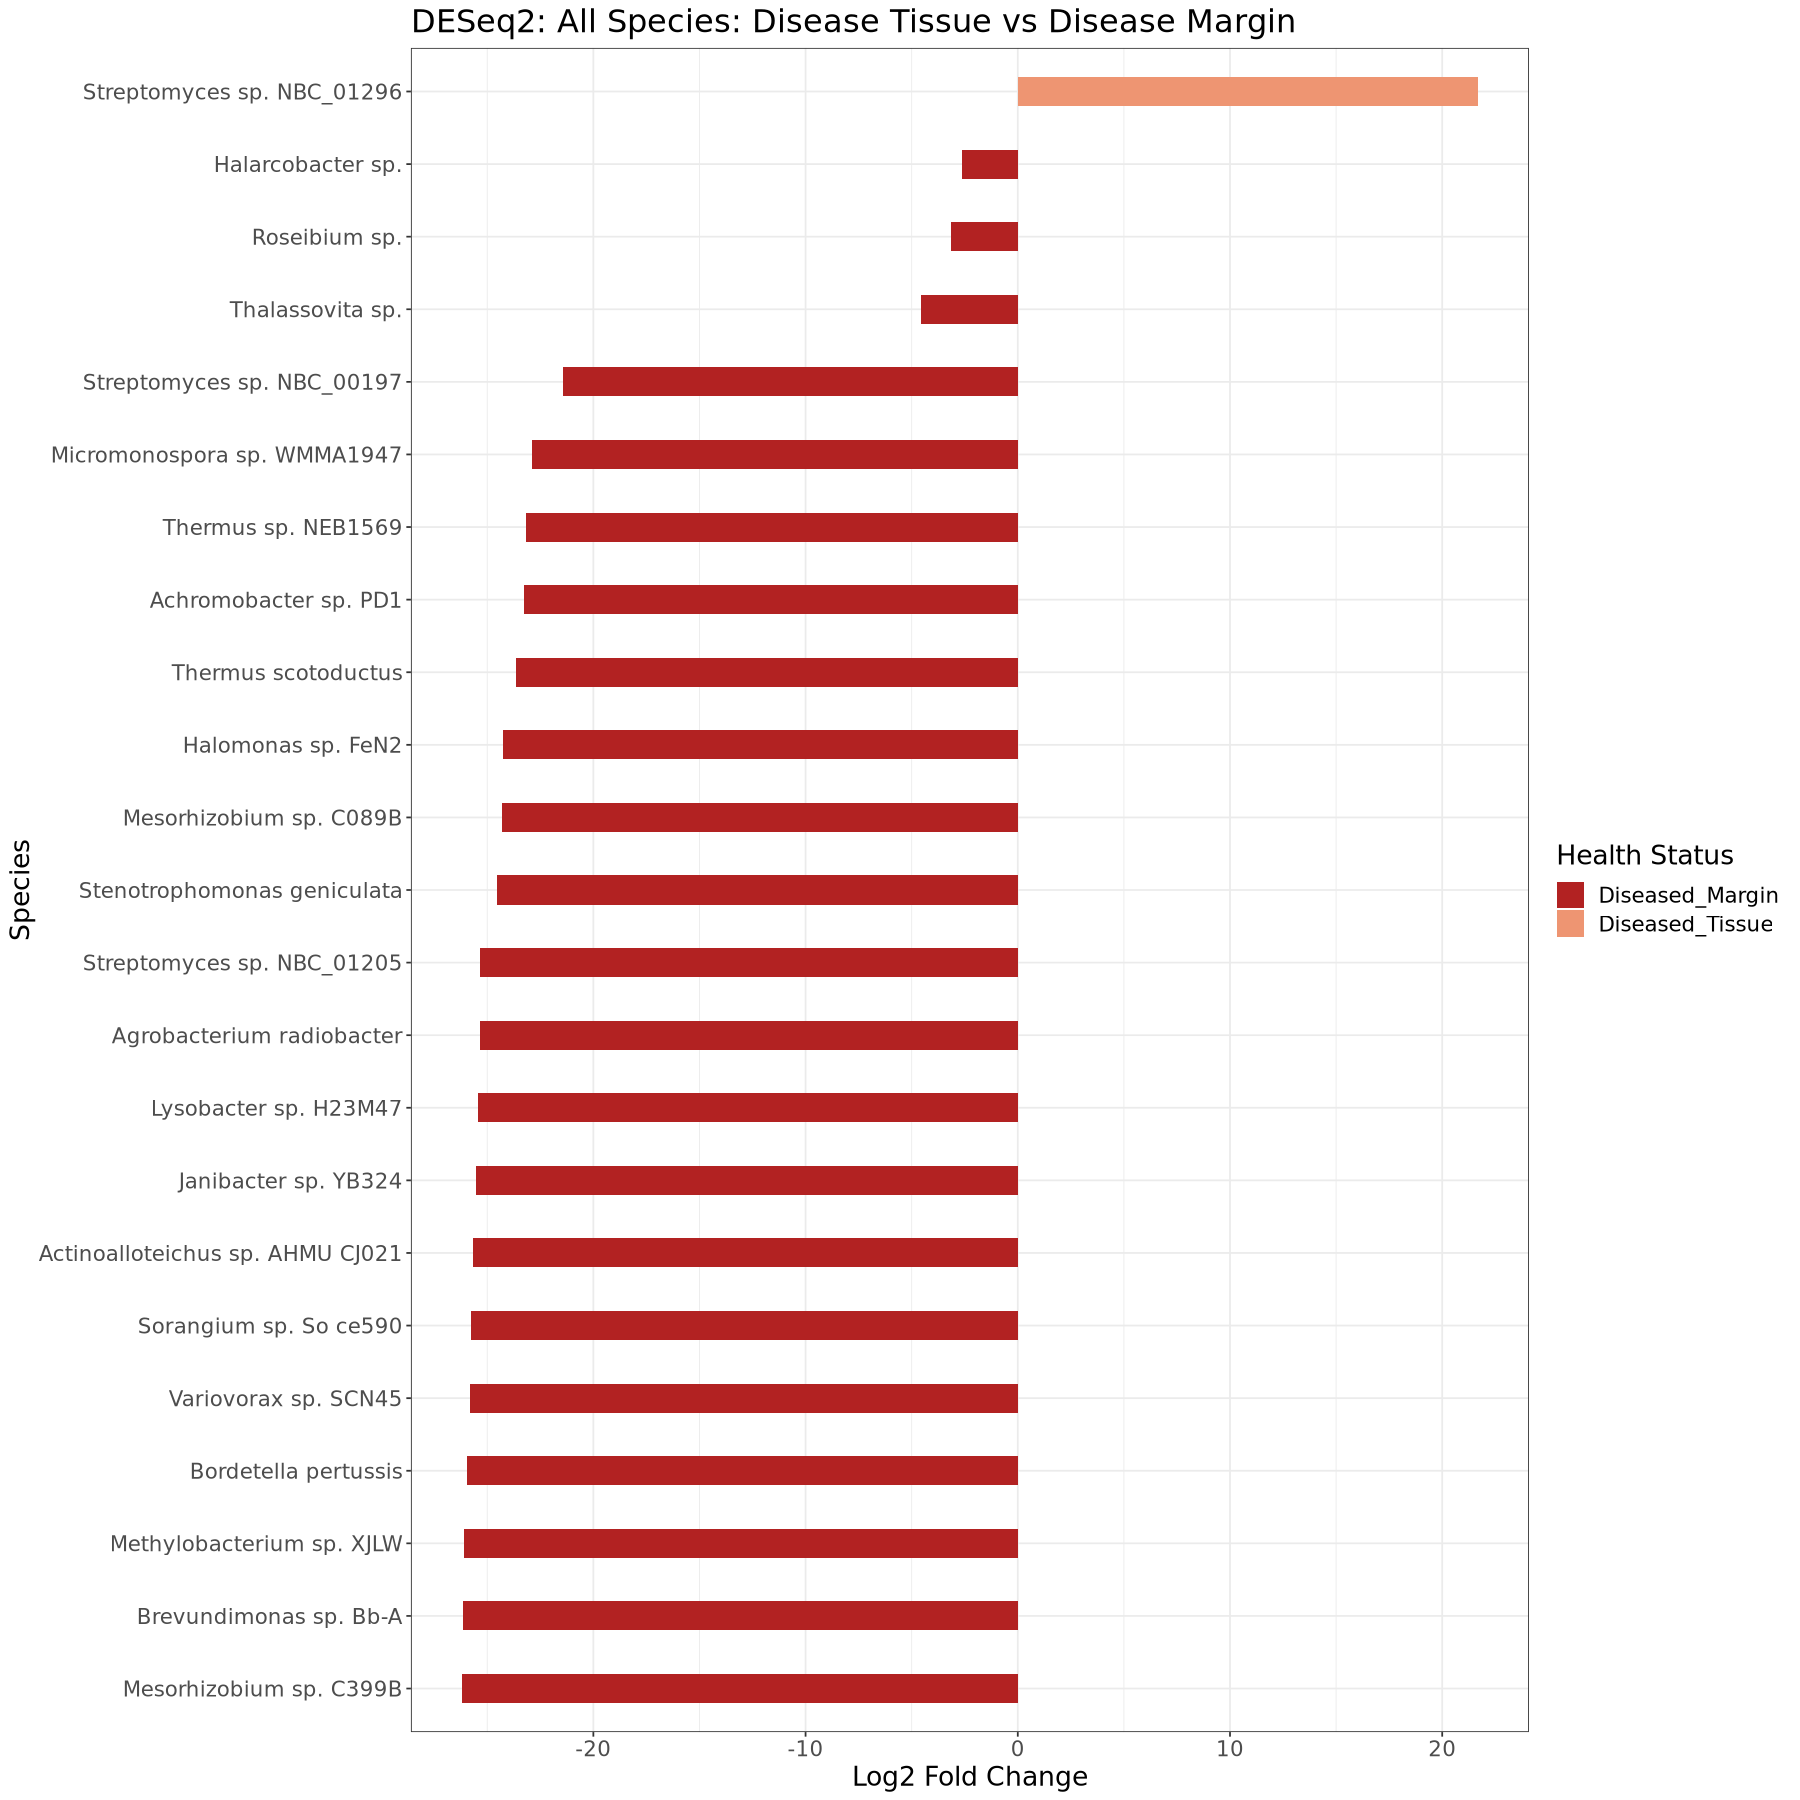

In [87]:
dm_dt_res<-view_ds_res(dm_dt_ds, comparison = "Health_status", contrast1 = "Diseased_Tissue",contrast2 = "Diseased_Margin")

# plot significantly different OTUs
ggplot(dm_dt_res, aes(x = reorder(species,log2FoldChange), y = log2FoldChange, fill = Health_status)) +
    geom_bar(stat = "identity", width = 0.4) +
    coord_flip() + 
    scale_fill_manual(values= c("Diseased_Tissue"="lightsalmon2", "Diseased_Margin"="firebrick"))+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: All Species: Disease Tissue vs Disease Margin", fill = "Health Status")+
    theme(text = element_text(size = 16)) 

In [88]:
# search for disease margin sig diff taxa in all disease samples
# youre deffs supposed to use kraken uniq for this 

In [89]:
sctld_assoc_otus<-rownames(dm_dt_res)

In [ ]:
# otu_table %>%
#     filter(rownames %in% sctld_assoc_otus)

In [468]:
sctld_assoc_taxa<-unique(dm_dt_res$species)

In [ ]:
## try within species comparisons too 

### Taxa Bar Plots

In [388]:
# subset taxa and normalzie out of 100 
sctld_all_10 = prune_taxa(names(sort(taxa_sums(sctld_all),TRUE)[1:10]), sctld_all)
sctld_all_10_norm <- transform_sample_counts(sctld_all_10, function(x) x / sum(x))
     
sctld_all_30 = prune_taxa(names(sort(taxa_sums(sctld_all),TRUE)[1:30]), sctld_all)
sctld_all_30_norm <- transform_sample_counts(sctld_all_30, function(x) x / sum(x))

sctld_all_100 = prune_taxa(names(sort(taxa_sums(sctld_all),TRUE)[1:100]), sctld_all)
sctld_all_100_norm <- transform_sample_counts(sctld_all_100, function(x) x / sum(x))

In [320]:
colors <- c( "#b73962", "#e994a6", "#be6b7c", "#944557", "#ea2c68", "#e65e74", "#b33841", "#dd3640", "#dd7267", "#de2b1c", "#a46452", "#c04926", "#9b4426", "#ec5825", "#e6a485", "#c2744d", "#e77d46", "#a3601b", "#845526", "#e28c23", "#d79651", "#a4844d", "#aa8523", "#d2b067", "#d3b135", "#726520", "#81871c", "#b4b75d", "#a5c030", "#829055", "#7a9a3c", "#566935", "#a7bc85", "#4e7023", "#64a422", "#89c45e", "#57ce3c", "#2f7f2d", "#3aa83a", "#5d9b58", "#7ec485", "#47cc7a", "#2c6f47", "#32a064", "#2f8970", "#53ae93", "#3fc9a6", "#64d3c2", "#41bbc8", "#3da5c4", "#4b8ebf", "#72b3e8", "#3270a7", "#2e5b88", "#4795e0", "#5790ed", "#2b6abe", "#2580fe", "#415691", "#6274b2", "#4b80ec", "#95a0e6", "#4362c2", "#7c89e9", "#5166ec", "#3c4dbb", "#5756a0", "#695dbf", "#8476c6", "#675cd3", "#4e45a3", "#4d4adc", "#8f76e8", "#72619d", "#9b87be", "#6b4fa0", "#7048b1", "#7532e8", "#b58aea", "#9655e8", "#cda8e4", "#7c608c", "#8a52ae", "#634872", "#bc6aea", "#b436e6", "#9235b6", "#7e4990", "#b175b9", "#9b43a1", "#dd7adc", "#e635ea", "#d043cc", "#915882", "#d78bbb", "#ba3291", "#ea3db5", "#a24680", "#e670af", "#e3418b" )
colors_30 <- c( "#e28d99", "#ee7473", "#f2703f", "#dc966f", "#de9435", "#d6b36e", "#dbbf37", "#abb160", "#bdd630", "#bade6b", "#7ead3b", "#bcdc9c", "#66d34d", "#65d77c", "#66af7a", "#5ae5ac", "#77e3c6", "#47b1a5", "#5ae4e5", "#41aec3", "#5eceed", "#3ba1d2", "#78b0e7", "#7796ed", "#b5a5dd", "#aa7df5", "#c891e3", "#e66dd5", "#de95c9", "#f2699f" )

In [414]:
options(repr.plot.height = 15, repr.plot.width = 30)

In [422]:
# view bar plot - all....

# idk how to plot all this
# try just each spp R vs S in 2019

sctld_100_2019<- subset_samples(sctld_all_100, year == "2019")
sctld_100_2019 = prune_taxa(names(sort(taxa_sums(sctld_100_2019),TRUE)[1:100]), sctld_100_2019)
sctld_100_2019_norm <- transform_sample_counts(sctld_100_2019, function(x) x / sum(x))

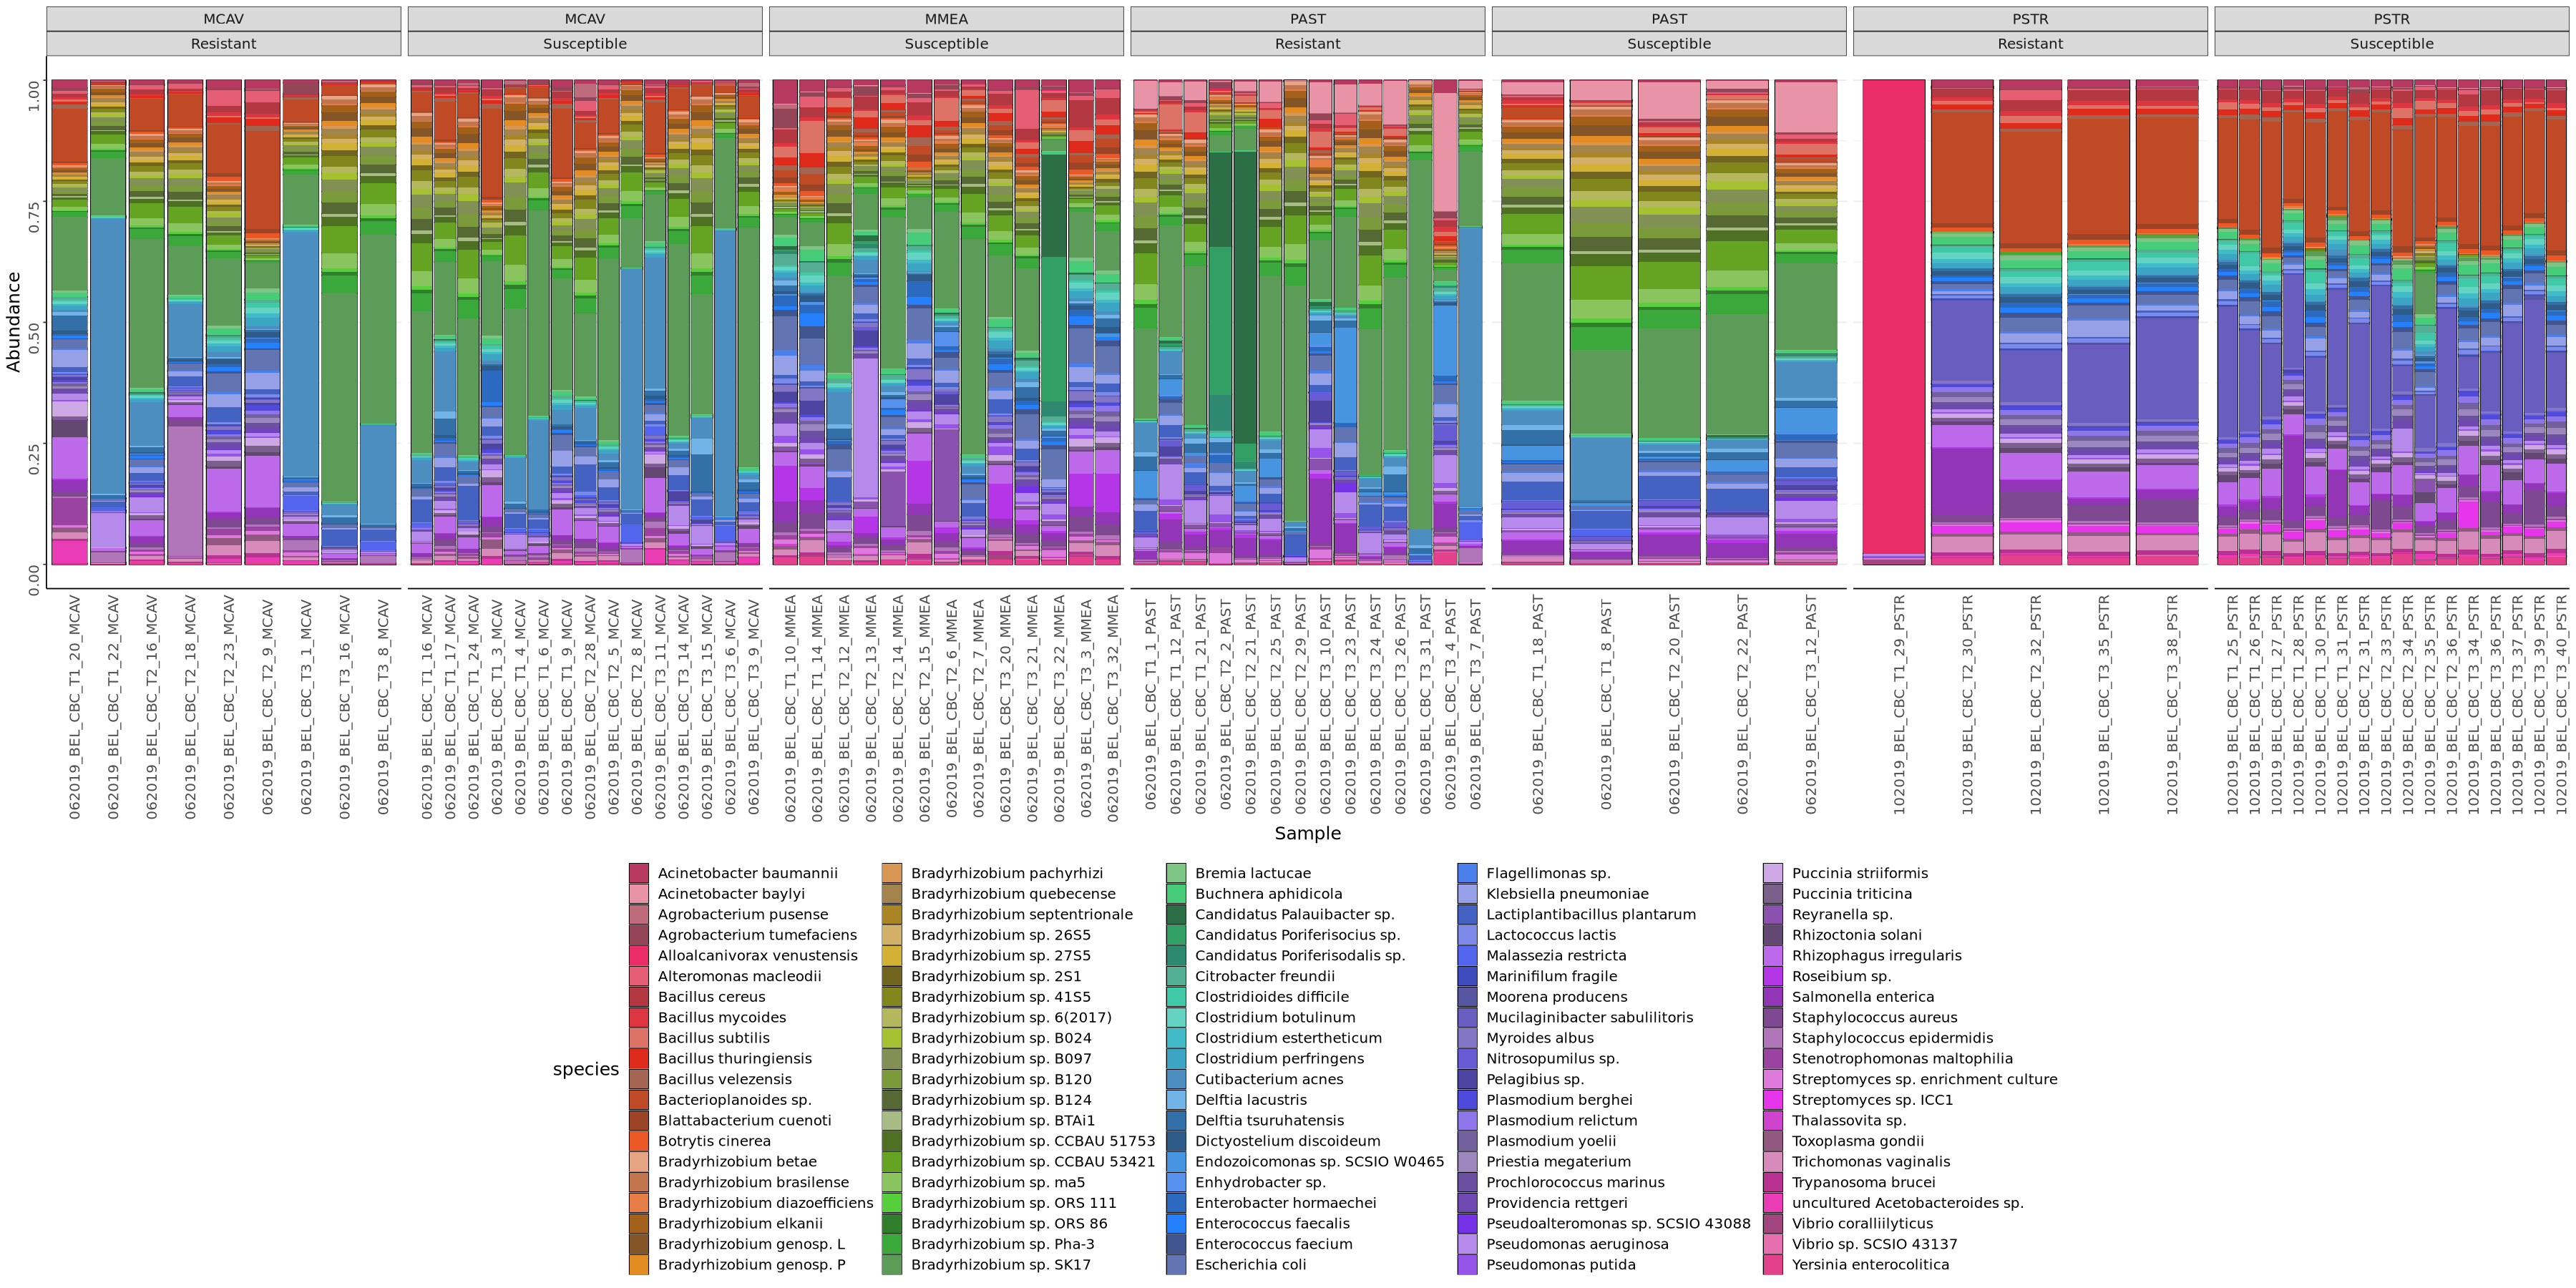

In [426]:
plot_bar(sctld_100_2019_norm,x = "Sample",fill='species')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(fill=species), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# found the PSTR outlier 

In [ ]:
# plot each spp individually...
    # guess i will try all RS

In [460]:
# looking just at mcav, remove disease margin

subset_mcav<- subset_samples(sctld_all, (Species == "MCAV" & Health_status != "Diseased_Margin"))

mcav_100 = prune_taxa(names(sort(taxa_sums(subset_mcav),TRUE)[1:100]), subset_mcav)
mcav_100_norm <- transform_sample_counts(mcav_100, function(x) x / sum(x))

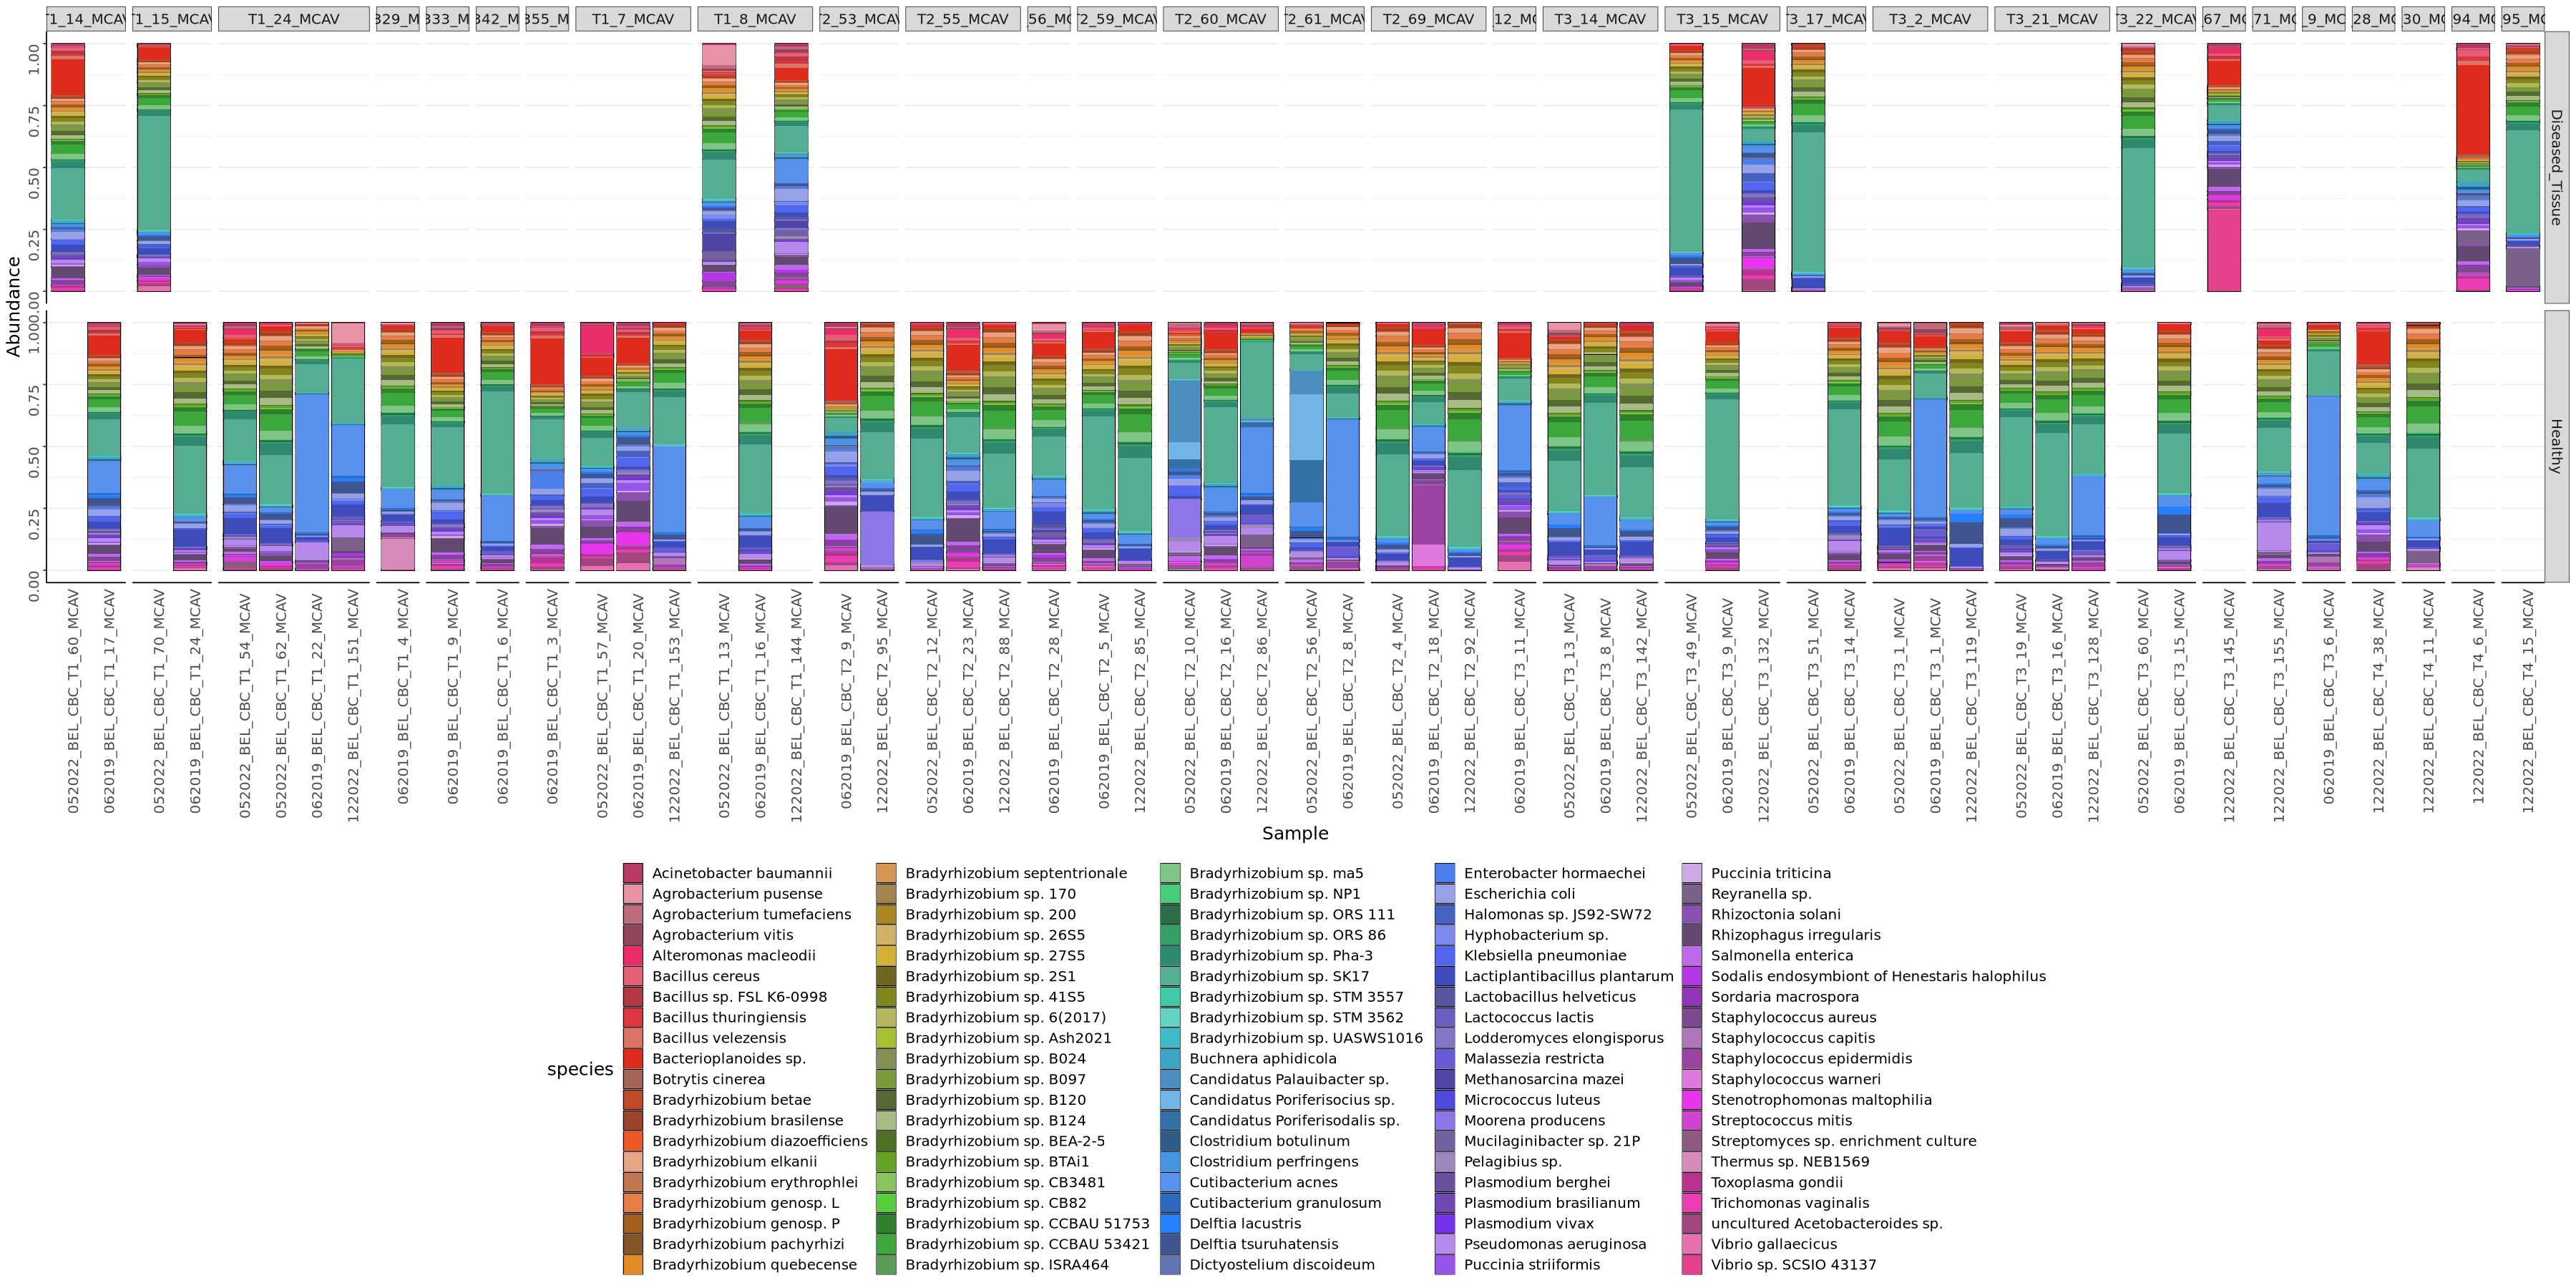

In [461]:
plot_bar(mcav_100_norm,x = "Sample",fill='species')+
    facet_grid(Health_status ~colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(fill=species), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# cannot figure out how to put in order of date...

In [ ]:
# is t1 24 mcav coded wrong? is it listed as healthy where it is not?

In [ ]:
# these bradyrhizobium are everywhere...